# WISE on BPIC'19 — full analysis · **EXTENDED / annotated edition**

This is the full all-views analysis with an **interpretation cell after every
figure and result**. Each annotation reads in the same three beats:

> **What you are looking at** → **Why it matters for a company improving its
> process** → **What decision or action it supports.**

The computation is identical to the standard full-analysis notebook; only the
explanatory narrative is added, plus a consolidated **Key insights & next steps**
summary at the very end. Run order and data loading are unchanged — point
`DATA_DIR_OVERRIDE` (cell 2) at your BPIC'19 CSV folder, or drop the CSV into
`data/`, then *Run All*.

---


In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===========================================================================
#  DATA LOCATION — the only thing you normally need to set.
#  Leave None  ->  the  data/  folder next to this notebook is used
#                  (any *.csv inside it is found automatically).
#  Or point it at your folder, e.g.  r"C:\Code\WISE_github\WISE\data"
# ===========================================================================
DATA_DIR_OVERRIDE = None

# --- locate the project root (folder containing wise_eval/) ---------------
import sys, os
from pathlib import Path

def _project_root():
    nb_path = globals().get("__vsc_ipynb_file__")
    if nb_path:
        p = Path(nb_path).resolve().parent
        if (p / "wise_eval" / "__init__.py").exists():
            return p
        if (p.parent / "wise_eval" / "__init__.py").exists():
            return p.parent
    for p in [Path.cwd(), *Path.cwd().parents]:
        if (p / "wise_eval" / "__init__.py").exists():
            return p
    for sub in sorted(Path.cwd().iterdir()):
        if sub.is_dir() and (sub / "wise_eval" / "__init__.py").exists():
            return sub
    raise FileNotFoundError("wise_eval/ not found — keep this notebook inside "
                            "the project folder and open that folder in VS Code/Jupyter.")

PROJECT_ROOT = _project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from wise_eval.config import CONFIG, RNG_SEED
from wise_eval import data as wdata, features as wfeat, norm as wnorm
from wise_eval import constraints as wcons, scoring as wsc
from wise_eval import prioritization as prio, governance as gov, viz

if DATA_DIR_OVERRIDE:
    CONFIG["csv_search_dirs"].insert(0, str(DATA_DIR_OVERRIDE))
    CONFIG["csv_candidates"].insert(0, str(Path(DATA_DIR_OVERRIDE) / "BPI_Challenge_2019.csv"))

# All figures of this notebook are written here (full load, every artefact):
CONFIG["figures_dir"] = str(PROJECT_ROOT / "figures" / "full")
Path(CONFIG["figures_dir"]).mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200); pd.set_option("display.width", 240)
np.random.seed(RNG_SEED)
VIEWS = ["Finance", "Logistics", "Compliance", "Automation"]
print(f"project root : {PROJECT_ROOT}")
print(f"figures dir  : {CONFIG['figures_dir']}")


project root : /Users/ula/code/PhD/WISE/WISE/Untitled
figures dir  : /Users/ula/code/PhD/WISE/WISE/Untitled/figures/full


In [2]:
# --- Load & prepare the event log (governance framing: fix the case notion) ---
df_raw, SOURCE, csv_path = wdata.load_raw_log()
df = wdata.prepare_log(df_raw)
n_docs = df["purchasing_document"].nunique()
print(f"\nData source : {SOURCE}" + (f"  ({csv_path})" if csv_path else "  (synthetic fallback with planted hotspots)"))
print(f"Event log   : {len(df):,} events | {df['case_id'].nunique():,} PO items | {n_docs:,} purchasing documents")
print("\nFlow-type case distribution (applicability backbone of the norm, paper Sec. V-A):")
flow_tab = (df.groupby("flow_type")["case_id"].nunique().rename("PO items")
            .to_frame().assign(share=lambda t: (t["PO items"]/t["PO items"].sum()).round(3)))
display(flow_tab)


[data] loading REAL BPIC'19 log: /Users/ula/code/PhD/WISE/WISE/Untitled/data/BPI_Challenge_2019.csv
[data] read 1,595,923 rows x 22 columns

Data source : BPIC19  (/Users/ula/code/PhD/WISE/WISE/Untitled/data/BPI_Challenge_2019.csv)
Event log   : 1,595,923 events | 251,734 PO items | 76,349 purchasing documents

Flow-type case distribution (applicability backbone of the norm, paper Sec. V-A):


,PO items,share
flow_type,,
2-way,1044,0.004
Consignment,14498,0.058
DF1,15182,0.060
DF2,221010,0.878



> ### 📖 Reading this result — the event log and its flow types
>
> **What you are looking at.** The log holds **1.6M events across ~251k PO line
> items grouped into ~76k purchasing documents**. The flow-type split (DF1, DF2,
> 2-way, consignment) is not a cosmetic breakdown — it is the *applicability
> backbone* of the whole analysis. Each flow type has different legitimate
> behaviour, so a check that is a real problem in one flow is normal in another.
>
> **Why it matters for the business.** Before any "deviation" can be trusted, the
> process has to be split into the execution models it actually runs. A 2-way item
> with no goods receipt is **not** a missing-receipt problem — that flow never
> expects one. Mixing flows is the single most common way process dashboards
> manufacture false alarms. WISE fixes the flow type *first* so that every later
> number is conditioned on "what should have happened for *this* kind of item".
>
> **What to do with it.** Confirm the flow-type mix matches what procurement and
> AP believe they run. A surprising share in any one flow (e.g. an unexpectedly
> large DF2 / invoice-before-goods population) is itself a finding worth raising,
> because DF2 carries the payment-block control logic where most timing risk sits.


In [3]:
# --- Phases 1+2: norm, bounded violations ν_c(σ), view scores S^(p)(σ), layer contributions Δλ ---
fc   = wfeat.build_case_features(df)
norm = wnorm.load_norm()
dfv, V, M = wcons.build_violation_matrix(fc, norm)
dflp = wsc.compute_layer_penalties(dfv, norm)
dvs, dcontrib = wsc.compute_view_scores(dflp, norm)
scores = wsc.assemble_case_scores(fc, dfv, dflp, dvs, dcontrib)

print(f"Norm: {len(norm['constraints'])} constraints in {len(norm['layers'])} layers | "
      f"V (cases × constraints): {V.shape} | applicability density M̄ = {M.mean():.1%}")
print("\nGLOBAL BASELINES μ̄^(p)   [paper Sec. V-B: 0.82 / 0.82 / 0.87 / 0.84]")
for v in VIEWS:
    s = scores[f"score__{v}"].dropna()
    print(f"  μ̄^({v:<10}) = {s.mean():.3f}   (mean weighted violation {1-s.mean():.1%}, {len(s):,} scored cases)")
chk = max(abs(scores[[c for c in scores.columns if c.startswith("contrib__Finance__")]].sum(axis=1)
              - (1 - scores["score__Finance"])).max(), 0)
print(f"\nExact layer decomposition check (Finance): max |Σ_λ Δλ − (1−S)| = {chk:.2e}  ✓")


Norm: 29 constraints in 7 layers | V (cases × constraints): (251734, 29) | applicability density M̄ = 76.2%

GLOBAL BASELINES μ̄^(p)   [paper Sec. V-B: 0.82 / 0.82 / 0.87 / 0.84]
  μ̄^(Finance   ) = 0.819   (mean weighted violation 18.1%, 251,734 scored cases)
  μ̄^(Logistics ) = 0.817   (mean weighted violation 18.3%, 251,734 scored cases)
  μ̄^(Compliance) = 0.871   (mean weighted violation 12.9%, 251,734 scored cases)
  μ̄^(Automation) = 0.844   (mean weighted violation 15.6%, 251,734 scored cases)

Exact layer decomposition check (Finance): max |Σ_λ Δλ − (1−S)| = 1.67e-16  ✓



> ### 📖 Reading this result — global baselines and the decomposition check
>
> **What you are looking at.** Four baseline scores $\bar\mu^{(p)}$, one per
> stakeholder view, each near **0.82–0.87** — i.e. an *average* item already
> satisfies most of its applicable norm, leaving a **13–18% weighted-violation
> budget** to explain. The decomposition check (`max |Σ Δλ − (1−S)| ≈ 1e-16`)
> proves the score is **exactly** the sum of its seven layer contributions.
>
> **Why it matters for the business.** Two things. First, the baseline is the
> **bar every segment is measured against** — a slice is only a "hotspot" if it is
> meaningfully *worse than this average*, which stops the organisation from chasing
> deviation that is simply normal background noise. Second, the exact decomposition
> is what makes the score **auditable**: any score can be opened up and traced to
> the precise layers and constraints that produced it, so finance and operations
> are never asked to act on a black-box number.
>
> **What to do with it.** Treat the four baselines as the *reference lines* for
> governance reporting. The fact that Compliance sits highest (0.87) and
> Finance/Logistics lowest (~0.82) already tells you the typical item is cleaner on
> control behaviour than on working-capital/handling behaviour — a first hint about
> where the systemic gaps live.


## 1 — The norm in full: layers, views, and all weights
Two-stage weights w_c^(p) = a_λ^(p)·b̂_c (paper Sec. IV-C, Table VIII).

TABLE VIII — layer weights a_λ^(p) per view (columns sum to 1):


,Finance,Logistics,Compliance,Automation
layer_name,,,,
Expected completion and closure,0.24,0.08,0.12,0.06
Flow-conditioned control discipline,0.08,0.24,0.30,0.08
Handovers and ageing,0.24,0.22,0.10,0.10
Rework and instability,0.06,0.22,0.06,0.28
Exceptions and corrections,0.08,0.08,0.26,0.06
Value and commercial integrity,0.24,0.04,0.06,0.08
Effort and automation friction,0.06,0.12,0.10,0.34



View rationale:
  Finance   : Finance prioritises unresolved items, ageing, and commercially relevant correction signals. Exposure-weighted PI is especially meaningful for this view.
  Logistics : Logistics emphasises correct 2-way/3-way flow behaviour, operational handovers, and receipt/rework instability.
  Compliance: Compliance focuses on the correct control path per process type and on explicit exception or correction events.
  Automation: Automation emphasises change loops, manual handling, many handoffs, and complex event chains that block touchless processing.

Full constraint weights w_c^(p) = a·b̂ (first 12 rows):


,layer_id,paper_type,b̂_c (normalised),w^(Finance),w^(Logistics),w^(Compliance),w^(Automation)
constraint_id,,,,,,,
c_l1_invoice_present,L1_closure_completeness,pres,0.3243,0.0778,0.0259,0.0389,0.0195
c_l1_clear_invoice_present,L1_closure_completeness,pres,0.3784,0.0908,0.0303,0.0454,0.0227
c_l1_goods_or_ses_present,L1_closure_completeness,pres,0.2973,0.0714,0.0238,0.0357,0.0178
c_l2_df1_invoice_after_goods,L2_flow_discipline,order,0.2857,0.0229,0.0686,0.0857,0.0229
c_l2_df2_release_after_goods,L2_flow_discipline,order,0.3061,0.0245,0.0735,0.0918,0.0245
c_l2_2way_no_goods_expected,L2_flow_discipline,excl,0.2449,0.0196,0.0588,0.0735,0.0196
c_l2_consignment_no_clear_invoice,L2_flow_discipline,excl,0.1633,0.0131,0.0392,0.0490,0.0131
c_l3_df1_goods_to_invoice_days,L3_timeliness_ageing,lag,0.2500,0.0600,0.0550,0.0250,0.0250
c_l3_invoice_to_clear_days,L3_timeliness_ageing,lag,0.2885,0.0692,0.0635,0.0288,0.0288


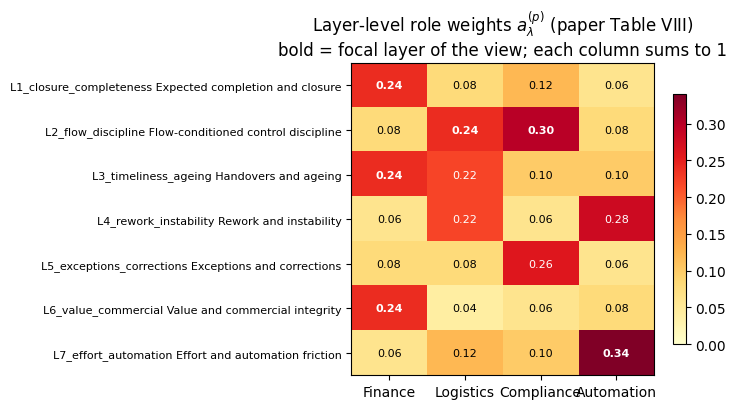

In [4]:
lt = wnorm.layer_weight_table(norm)
print("TABLE VIII — layer weights a_λ^(p) per view (columns sum to 1):")
display(lt.set_index("layer_name").round(2) if "layer_name" in lt.columns else lt.round(2))
viz.fig_layer_weights(lt, name="layer_weights")
print("\nView rationale:")
for v, spec in norm["views"].items():
    print(f"  {v:<10}: {spec.get('why', spec.get('description', '—'))}")
print("\nFull constraint weights w_c^(p) = a·b̂ (first 12 rows):")
display(wnorm.raw_constraint_weights(norm).head(12).round(4))



> ### 📖 Reading this result — the four views are genuine priorities, not relabels
>
> **What you are looking at.** The layer-weight table is the **only** thing that
> differs between the four views; the underlying constraints and violations are
> identical. Finance loads closure, ageing and value; Logistics loads flow
> discipline, handovers and stability; Compliance loads control and exceptions;
> Automation loads rework and manual effort. Each column sums to 1.
>
> **Why it matters for the business.** This is how WISE encodes the reality that
> **different owners legitimately disagree about what "bad" means**. The same
> delayed-clearing item is a working-capital problem to Finance, a throughput
> problem to Logistics, and barely interesting to Compliance. Making those
> trade-offs *explicit weights* — rather than burying them in separate dashboards —
> means the disagreement can be discussed and governed instead of relitigated every
> meeting.
>
> **What to do with it.** Use this table as the artefact you actually negotiate
> with stakeholders. If a head of AP thinks ageing should matter more, you change
> one weight and re-rank — you do **not** rebuild the analysis. That editability is
> the practical payoff of the shared-norm / multiple-view design.


## 2 — Phase-2 evidence across all views

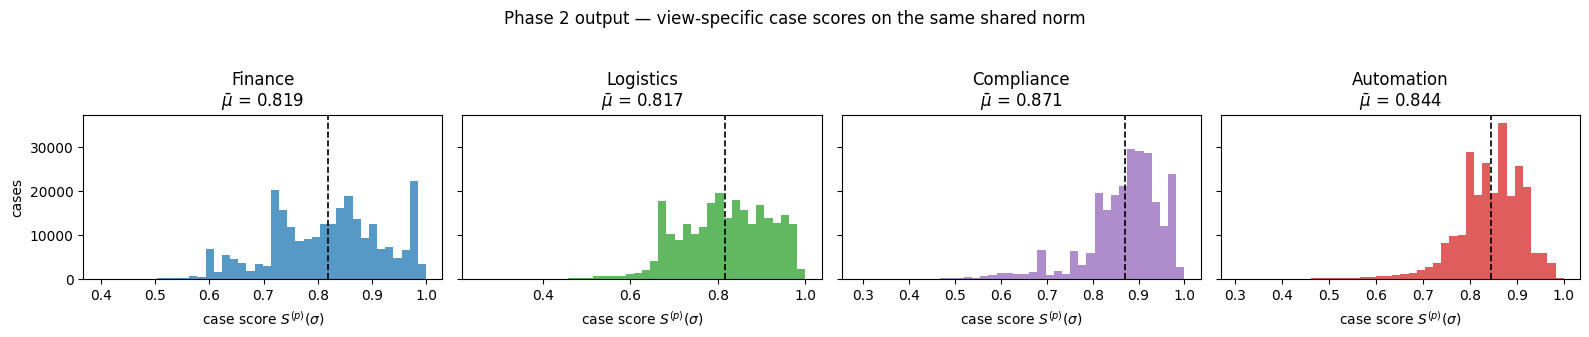

In [5]:
viz.fig_score_distributions(scores, VIEWS, name="score_distributions_all_views");



> ### 📖 Reading this figure — the shape of the score, not just its average
>
> **What you are looking at.** The per-view distribution of case scores. A tall
> spike near 1.0 with a left tail is the signature you want: **most items are fine,
> a minority drag the average down**. The dashed line is the baseline mean.
>
> **Why it matters for the business.** The *shape* decides the improvement
> strategy. A left-skewed spike (what we see here) means the problem is
> concentrated in a tail you can isolate and fix — a backlog you can work down. A
> broad, symmetric spread would instead mean the process is *uniformly* mediocre,
> which calls for a redesign rather than targeted clean-up. Reading the shape stops
> you from picking the wrong kind of intervention.
>
> **What to do with it.** Note how much wider the Finance/Logistics tails are than
> Compliance's — the working-capital and handling lenses see more spread, i.e. more
> recoverable value sits there. That is your first signal of *which view's backlog*
> is worth working first.


GLOBAL MECHANISM SIGNALS (view-independent)              [paper, real log]
  1.  22.6% of invoice-bearing items never reach Clear Invoice        [22.6%]  → L1 closure
  2.  88.9% of applicable items show positive IR→CI ageing severity   [68.7%]  → L3 ageing
  3.  10.9% of invoice-bearing items lack invoice evidence            [10.9%]  → L1 completeness
  4.   6.4% of 3-way items lack GR/SES evidence                       [ 6.4%]  → L1 completeness

DOMINANT WEIGHTED LAYER PER VIEW (mean Δλ over all cases)  [paper: L3 for Fin/Log/Compl, L7 for Automation]


,Finance,Logistics,Compliance,Automation
L1_closure_completeness Expected completion and closure,0.0456,0.0188,0.0255,0.0095
L2_flow_discipline Flow-conditioned control discipline,0.0020,0.0059,0.0073,0.0020
L3_timeliness_ageing Handovers and ageing,0.1078,0.1123,0.0541,0.0449
L4_rework_instability Rework and instability,0.0010,0.0041,0.0011,0.0043
L5_exceptions_corrections Exceptions and corrections,0.0019,0.0023,0.0070,0.0013
L6_value_commercial Value and commercial integrity,0.0054,0.0010,0.0015,0.0017
L7_effort_automation Effort and automation friction,0.0173,0.0386,0.0328,0.0920


  Finance    → dominant layer: L3_timeliness_ageing Handovers and ageing
  Logistics  → dominant layer: L3_timeliness_ageing Handovers and ageing
  Compliance → dominant layer: L3_timeliness_ageing Handovers and ageing
  Automation → dominant layer: L7_effort_automation Effort and automation friction


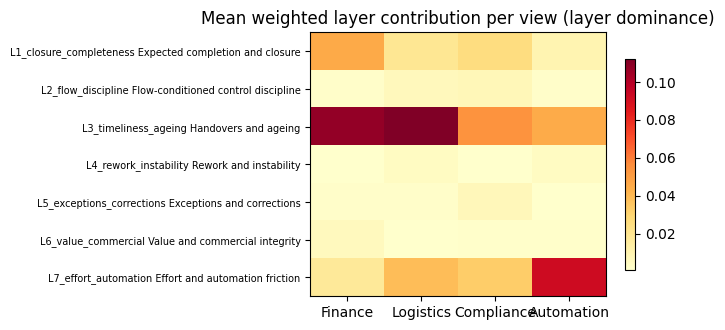

In [6]:
# --- The four view-independent global signals of paper Sec. V-C (Q3.2) ----
def _cnt(col):
    return scores[col].fillna(0) if col in scores.columns else pd.Series(0.0, index=scores.index)

inv_flows  = scores["flow_type"].isin(["DF1", "DF2", "2-way"])      # invoicing expected
three_way  = scores["flow_type"].isin(["DF1", "DF2"])               # GR/SES expected
has_inv    = (_cnt("count__record_invoice_receipt") + _cnt("count__vendor_creates_invoice")) > 0
has_clear  = _cnt("count__clear_invoice") > 0
has_grses  = (_cnt("count__record_goods_receipt") + _cnt("count__record_service_entry_sheet")) > 0

s1 = (inv_flows & ~has_clear).sum() / max(inv_flows.sum(), 1)        # open / missing closure
age_col = next((c for c in scores.columns if "invoice_to_clear" in c and c.startswith("c_")), None)
age = scores[age_col] if age_col else pd.Series(dtype=float)
s2 = (age > 0).sum() / max(age.notna().sum(), 1)                     # positive IR→CI ageing
s3 = (inv_flows & ~has_inv).sum() / max(inv_flows.sum(), 1)          # missing invoice evidence
s4 = (three_way & ~has_grses).sum() / max(three_way.sum(), 1)        # missing GR/SES

print("GLOBAL MECHANISM SIGNALS (view-independent)              [paper, real log]")
print(f"  1. {s1:6.1%} of invoice-bearing items never reach Clear Invoice        [22.6%]  → L1 closure")
print(f"  2. {s2:6.1%} of applicable items show positive IR→CI ageing severity   [68.7%]  → L3 ageing")
print(f"  3. {s3:6.1%} of invoice-bearing items lack invoice evidence            [10.9%]  → L1 completeness")
print(f"  4. {s4:6.1%} of 3-way items lack GR/SES evidence                       [ 6.4%]  → L1 completeness")

print("\nDOMINANT WEIGHTED LAYER PER VIEW (mean Δλ over all cases)  "
      "[paper: L3 for Fin/Log/Compl, L7 for Automation]")
dom_rows = {}
for v in VIEWS:
    m = scores[[f"contrib__{v}__{l}" for l in norm["layers"]]].mean()
    m.index = list(norm["layers"].keys())
    dom_rows[v] = m
layer_dom = pd.DataFrame(dom_rows)
layer_dom.index = [f"{l} {norm['layers'][l]['name']}" for l in layer_dom.index]
display(layer_dom.round(4))
import matplotlib.pyplot as _plt
_fig, _ax = _plt.subplots(figsize=(7,3.4))
_im = _ax.imshow(layer_dom.values, cmap="YlOrRd", aspect="auto")
_ax.set_xticks(range(len(VIEWS)), VIEWS); _ax.set_yticks(range(len(layer_dom)), layer_dom.index, fontsize=7)
_ax.set_title("Mean weighted layer contribution per view (layer dominance)")
_fig.colorbar(_im, ax=_ax, shrink=0.8); _fig.tight_layout()
_fig.savefig(Path(CONFIG["figures_dir"])/"layer_dominance.png", dpi=150, bbox_inches="tight")
for v in VIEWS:
    print(f"  {v:<10} → dominant layer: {layer_dom[v].idxmax()}")



> ### 📖 Reading this result — the four raw signals that explain everything downstream
>
> **What you are looking at.** Four **view-independent** facts about the raw log:
> ~**22.6%** of invoice-bearing items never reach `Clear Invoice`; ~**68.7%** show
> positive invoice→clear ageing; ~**10.9%** lack invoice evidence; ~**6.4%** of
> 3-way items lack GR/SES. The dominant-layer table then shows L3 (handovers &
> ageing) leads for Finance/Logistics/Compliance, while L7 (effort) leads for
> Automation — *because* its weights point there.
>
> **Why it matters for the business.** This is the headline diagnosis: **a large
> part of the process behaves like slowly-resolved work-in-progress.** The dominant
> problem is not exotic exceptions or fraud — it is *things not getting closed and
> cleared on time*. That single sentence reframes the improvement programme from
> "hunt for anomalies" to "**resolve a backlog and tighten settlement timeliness**",
> which is a completely different (and cheaper) kind of work.
>
> **What to do with it.** Carry the 22.6% open-item figure into the governance loop
> with a caveat flag — some of it is genuine backlog, some is just items that
> hadn't finished when the data was extracted (right-censoring, validated later in
> Section 7). Do **not** quote it as a clean process-failure rate until that check
> is done.


## 3 — Q3.1 for every view: document backlogs and concentration

  Finance   :  2,039 headers =  2.7% capture 80%   |    7,643 = 10.0% capture 95%
  Logistics :  2,110 headers =  2.8% capture 80%   |    7,420 =  9.7% capture 95%
  Compliance:  1,771 headers =  2.3% capture 80%   |    7,012 =  9.2% capture 95%
  Automation:  2,083 headers =  2.7% capture 80%   |    7,722 = 10.1% capture 95%


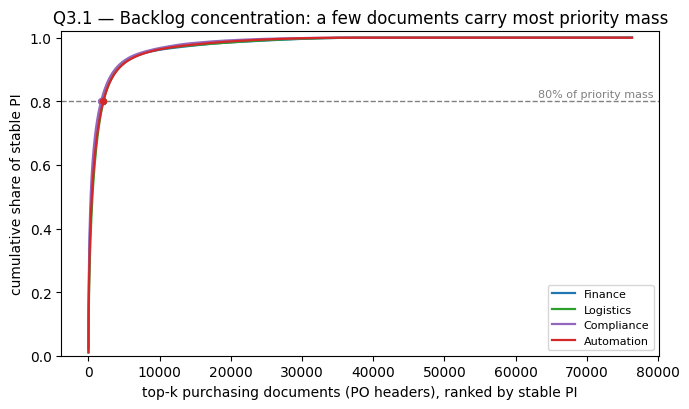

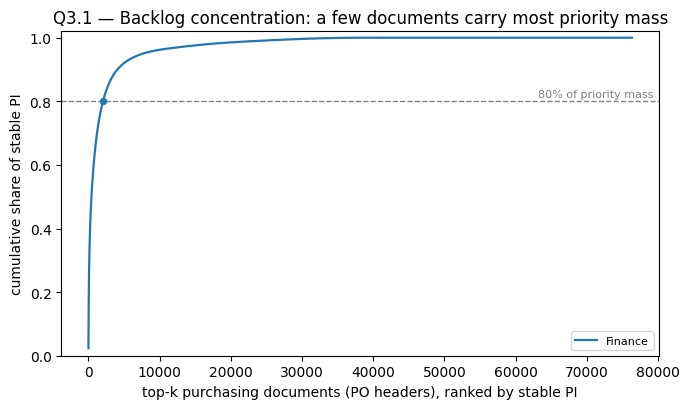

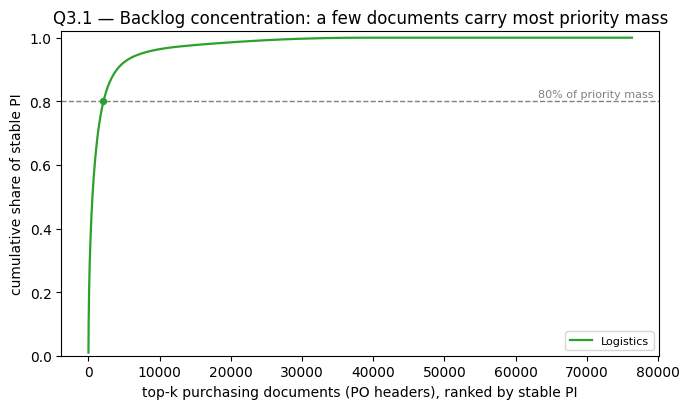

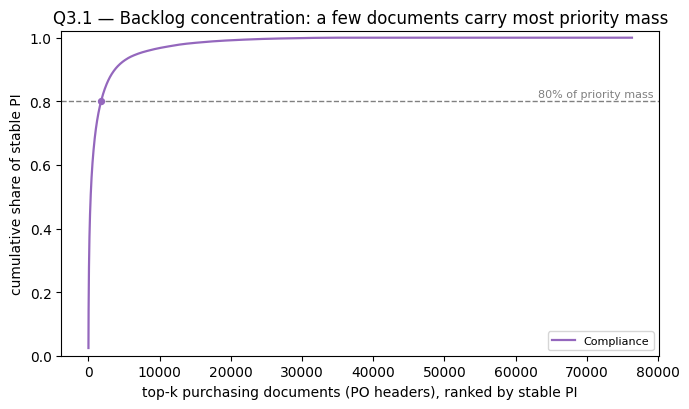

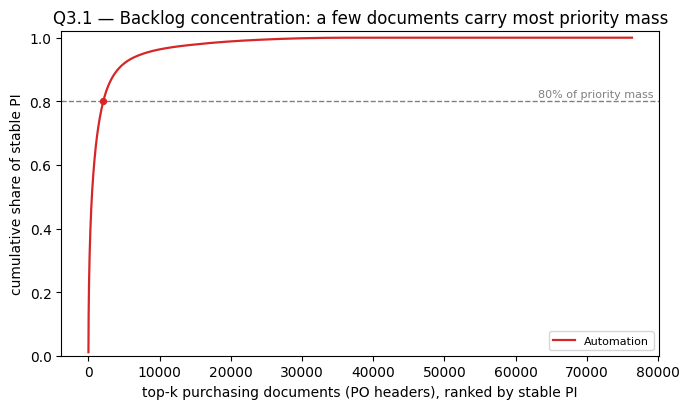

In [7]:
doc_backlogs, doc_cums = {}, {}
for v in VIEWS:
    bl = prio.document_backlog(scores, v)
    conc, cum = prio.pareto_concentration(bl)
    doc_backlogs[v], doc_cums[v] = bl, cum
    (k80, s80), (k95, s95) = conc[0.80], conc[0.95]
    print(f"  {v:<10}: {k80:>6,} headers = {s80:5.1%} capture 80%   |   {k95:>6,} = {s95:5.1%} capture 95%")
viz.fig_document_pareto(doc_cums, name="document_pareto_all_views")
for v in VIEWS:
    viz.fig_document_pareto({v: doc_cums[v]}, name=f"document_pareto_{v.lower()}")



> ### 📖 Reading this figure — the backlog is bounded, not boundless
>
> **What you are looking at.** Cumulative priority mass against the number of
> top-ranked PO headers. The curve rises **steeply then flattens**: roughly
> **2–3% of purchasing documents carry 80% of the stable priority**, and under 10%
> carry 95% — in every view.
>
> **Why it matters for the business.** This is the most important *managerial*
> result in the whole notebook. It converts an open-ended question ("which of our
> 76,000 documents are problematic?") into a **finite, assignable review list of a
> couple of thousand documents**. Improvement capacity is always scarce; this curve
> says you do not need an organisation-wide campaign — a focused team working a
> bounded backlog captures the vast majority of the recoverable value. That is the
> Pareto "vital few" made concrete and auditable.
>
> **What to do with it.** Pick the operating point off the curve. "Top 2,000
> documents" is a quarter's worth of structured review for a small team; "top 200"
> is a pilot. The flattening tail tells you where extra effort stops paying off.


,Finance,Logistics,Compliance,Automation
Finance,1.000,0.143,0.481,0.081
Logistics,0.143,1.000,0.212,0.250
Compliance,0.481,0.212,1.000,0.143
Automation,0.081,0.250,0.143,1.000


,Finance,Logistics,Compliance,Automation
Finance,1.000,0.782,0.817,0.570
Logistics,0.782,1.000,0.767,0.771
Compliance,0.817,0.767,1.000,0.617
Automation,0.570,0.771,0.617,1.000


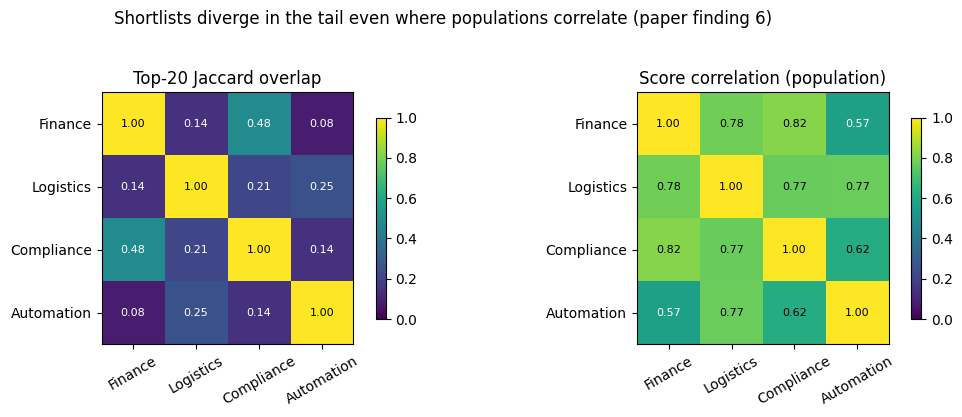

In [8]:
# Cross-view overlap: Jaccard of top-20 shortlists + score correlations
jac = prio.jaccard_topk(doc_backlogs, k=CONFIG["top_k_documents"])
corr = scores[[f"score__{v}" for v in VIEWS]].corr(); corr.index = corr.columns = VIEWS
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, mat, title in [(axes[0], jac.astype(float), f"Top-{CONFIG['top_k_documents']} Jaccard overlap"),
                       (axes[1], corr, "Score correlation (population)")]:
    im = ax.imshow(mat.values, cmap="viridis", vmin=0, vmax=1)
    ax.set_xticks(range(len(VIEWS)), VIEWS, rotation=30); ax.set_yticks(range(len(VIEWS)), VIEWS)
    for i in range(len(VIEWS)):
        for j in range(len(VIEWS)):
            ax.text(j, i, f"{mat.values[i,j]:.2f}", ha="center", va="center",
                    color="white" if mat.values[i,j] < 0.6 else "black", fontsize=8)
    ax.set_title(title); fig.colorbar(im, ax=ax, shrink=0.8)
fig.suptitle("Shortlists diverge in the tail even where populations correlate (paper finding 6)", y=1.03)
fig.tight_layout(); fig.savefig(Path(CONFIG["figures_dir"])/"view_overlap.png", dpi=150, bbox_inches="tight")
display(jac.round(3)); display(corr.round(3))



> ### 📖 Reading this figure — why "which view" is a real decision
>
> **What you are looking at.** Two matrices: top-20 **Jaccard overlap** of the
> shortlists, and **population score correlation**. The crucial contrast: Finance
> and Compliance scores correlate strongly, yet their *action shortlists* overlap
> only moderately; Finance and Automation diverge sharply on both.
>
> **Why it matters for the business.** Scores can move together while the **extreme
> tail you actually act on pulls apart**. In plain terms: two stakeholders can
> "broadly agree the process is fine on average" and still want to review almost
> entirely **different documents first**. If you let one team's lens silently drive
> the backlog, you are making a substantive prioritisation choice on everyone else's
> behalf without anyone deciding it.
>
> **What to do with it.** Treat the choice of view as a **governance decision**, not
> a default. A practical pattern: run Compliance for the control/audit backlog and
> Automation for the efficiency/rework backlog *in parallel*, and only merge where
> the shortlists overlap (those are the cross-cutting, unarguable priorities).


## 4 — Q3.1/Q3.2 for every view: slice backlogs, typology, risk matrices

In [9]:
SLICE_KEYS = CONFIG["slice_keys"]
backlogs, typeds = {}, {}
for v in VIEWS:
    backlogs[v] = prio.slice_backlog(scores, v, SLICE_KEYS)
    typeds[v]   = prio.classify_hotspots(backlogs[v], top_n=12)
    print(f"\n=== TOP SLICES — {v} view (stable PI, γ = {CONFIG['shrinkage_gamma']:.0f}) ===")
    display(typeds[v][SLICE_KEYS + ["cases", "slice_mean", "stable_gap", "PI_stable", "hotspot_type"]]
            .head(8).round(4))



=== TOP SLICES — Finance view (stable PI, γ = 20) ===


,case Company,case Spend area text,cases,slice_mean,stable_gap,PI_stable,hotspot_type
0,companyID_0000,Packaging,109199,0.7982,0.0210,2289.2907,reservoir
1,companyID_0000,Logistics,5242,0.7207,0.0981,514.1378,mechanism
2,companyID_0000,(missing),3257,0.7773,0.0415,135.2346,mechanism
3,companyID_0000,Trading & End Products,22292,0.8133,0.0058,129.1904,mechanism
4,companyID_0000,Marketing,1789,0.7905,0.0283,50.6907,mechanism
5,companyID_0000,Additives,18318,0.8164,0.0027,49.9525,mechanism
6,companyID_0003,Real Estate,583,0.7828,0.0351,20.4710,mechanism
7,companyID_0003,Enterprise Services,122,0.7402,0.0678,8.2719,mechanism



=== TOP SLICES — Logistics view (stable PI, γ = 20) ===


,case Company,case Spend area text,cases,slice_mean,stable_gap,PI_stable,hotspot_type
0,companyID_0000,Packaging,109199,0.7944,0.0225,2460.6494,mechanism
1,companyID_0000,Logistics,5242,0.7653,0.0515,270.0081,mechanism
2,companyID_0000,Additives,18318,0.8095,0.0074,135.8756,mechanism
3,companyID_0000,Marketing,1789,0.7790,0.0376,67.2078,mechanism
4,companyID_0000,Latex & Monomers,5007,0.8100,0.0069,34.5260,mechanism
5,companyID_0000,Workforce Services,127,0.6865,0.1127,14.3133,mechanism
6,companyID_0000,(missing),3257,0.8155,0.0015,4.7671,reservoir
7,companyID_0000,Spend Area Unidentified,36,0.6627,0.0992,3.5706,severity



=== TOP SLICES — Compliance view (stable PI, γ = 20) ===


,case Company,case Spend area text,cases,slice_mean,stable_gap,PI_stable,hotspot_type
0,companyID_0000,Packaging,109199,0.8626,0.0081,881.9916,mechanism
1,companyID_0000,Logistics,5242,0.8086,0.0618,323.9355,mechanism
2,companyID_0000,(missing),3257,0.8298,0.0406,132.2794,mechanism
3,companyID_0000,Trading & End Products,22292,0.8652,0.0054,121.2285,reservoir
4,companyID_0000,Marketing,1789,0.8325,0.0377,67.4988,mechanism
5,companyID_0000,Additives,18318,0.8679,0.0028,51.3279,mechanism
6,companyID_0000,Latex & Monomers,5007,0.8608,0.0098,49.0637,mechanism
7,companyID_0000,Workforce Services,127,0.6925,0.1540,19.5524,mechanism



=== TOP SLICES — Automation view (stable PI, γ = 20) ===


,case Company,case Spend area text,cases,slice_mean,stable_gap,PI_stable,hotspot_type
0,companyID_0000,Packaging,109199,0.8357,0.0087,945.7214,reservoir
1,companyID_0000,Logistics,5242,0.7880,0.0561,294.1742,mechanism
2,companyID_0000,Additives,18318,0.8346,0.0097,177.7888,mechanism
3,companyID_0000,Latex & Monomers,5007,0.8265,0.0177,88.8325,mechanism
4,companyID_0003,Real Estate,583,0.7545,0.0869,50.6384,mechanism
5,companyID_0000,(missing),3257,0.8331,0.0111,36.2934,mechanism
6,companyID_0000,Solvents,2629,0.8363,0.0080,20.9424,mechanism
7,companyID_0000,Specialty Resins,2406,0.8389,0.0054,13.1063,mechanism



> ### 📖 Reading these tables — three kinds of "high priority" that need different fixes
>
> **What you are looking at.** Per-view ranked slice backlogs, each row tagged
> **reservoir / mechanism / severity**. The same name recurs at the top across
> views — `companyID_0000 × Packaging` (huge volume, small gap) and
> `companyID_0000 × Logistics` (smaller, larger gap) — but their *hotspot type*
> differs, and one row, `companyID_0000 × (missing)`, flags items with **no spend
> area assigned at all**.
>
> **Why it matters for the business.** A single PI number hides *why* a slice is on
> the list, and the "why" dictates the intervention:
> - **Reservoir** (Packaging): moderate gap × enormous volume. Small frictions
>   compounding at scale → **queue/backlog management**, SLAs, workload balancing.
> - **Mechanism** (Logistics): a *specific recurring* defect concentrates here →
>   **targeted redesign / automation** of that step.
> - **Severity** (Real Estate, Enterprise Services): tiny volume, large gap → a
>   **local policy/config issue** to review in a room, not re-engineer.
>
> Treating all three as "the top of the list" and throwing the same project at them
> is the classic way improvement programmes waste effort.
>
> **What to do with it.** The `(missing)` spend-area slice is a free win: it is very
> likely a **master-data / categorisation gap**, not a process defect. Fixing the
> data assignment may make that "hotspot" disappear — and improves every future
> report. Always check master data before launching a process project on a slice.


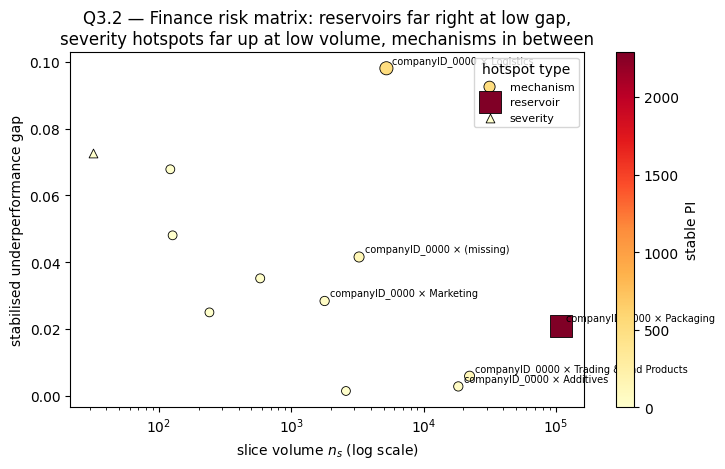

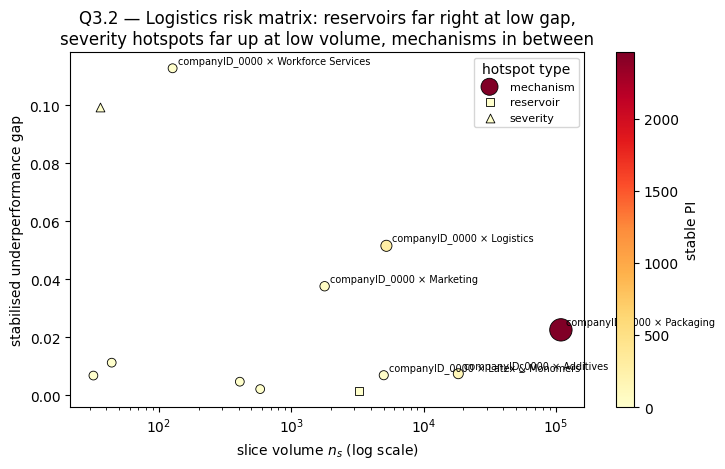

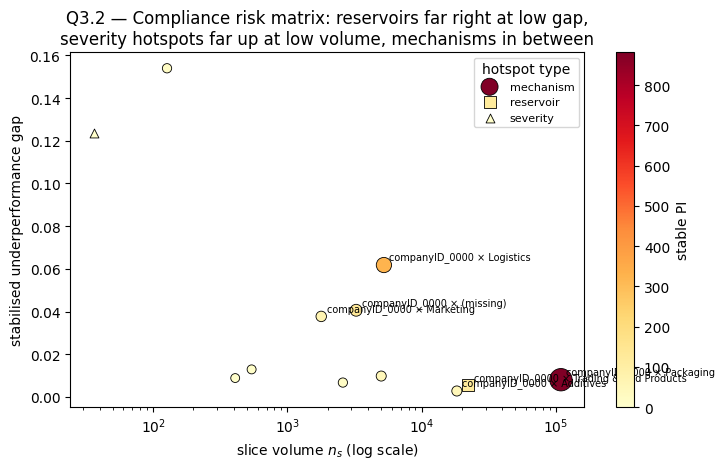

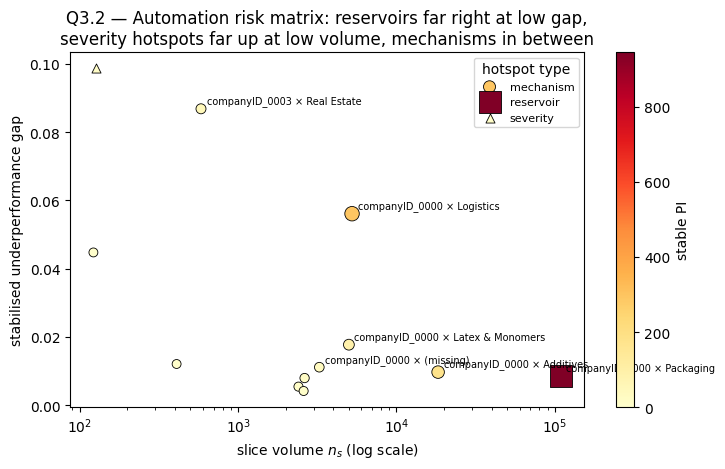

In [10]:
for v in VIEWS:
    viz.fig_risk_matrix(typeds[v], SLICE_KEYS, v, name=f"risk_matrix_{v.lower()}")



> ### 📖 Reading these figures — the scale-vs-severity map
>
> **What you are looking at.** Each slice plotted as **volume (x) × stabilised
> underperformance (y)**, coloured by priority. The three hotspot types occupy
> distinct regions: reservoirs sit **far right, low** (big and mildly bad);
> severity hotspots sit **top, far left** (small and acutely bad); mechanisms sit
> between.
>
> **Why it matters for the business.** This is the one picture to put in front of a
> steering committee. It makes the prioritisation logic *visible and defensible*:
> nobody has to take the ranking on faith because they can see **why** each slice
> sits where it does. It also prevents the two opposite mistakes — ignoring a
> low-gap reservoir because the gap looks small (it's huge × small = large
> exposure), and over-investing in a high-gap severity dot that affects 500 items.
>
> **What to do with it.** Read the axes as an action map: **right → manage the
> queue, up → fix the local cause, middle → redesign the mechanism.** Where a slice
> sits tells you which playbook to open before you have looked at a single trace.


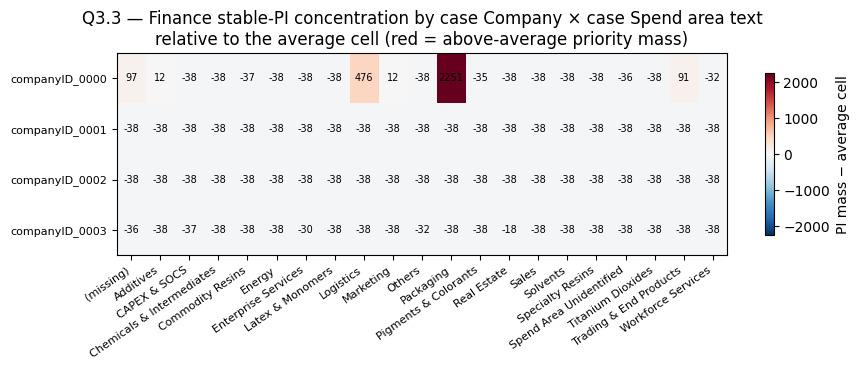

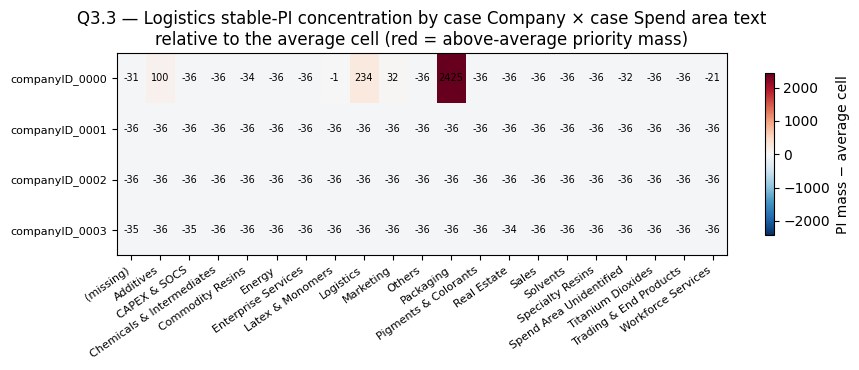

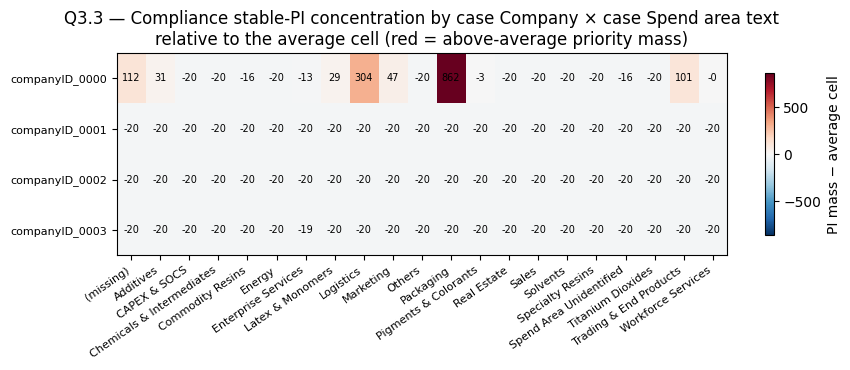

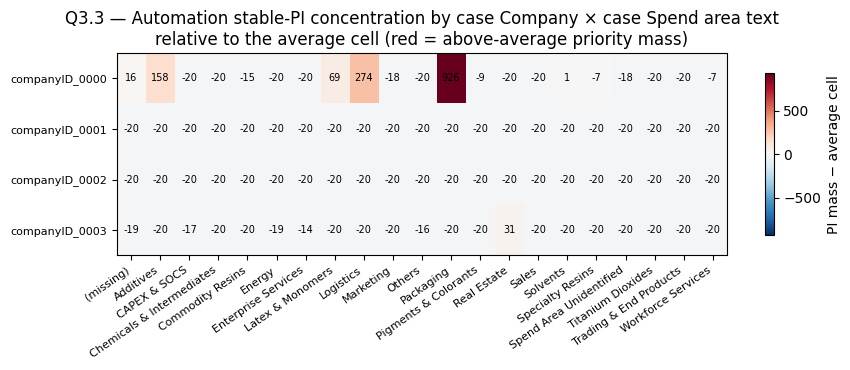

In [11]:
for v in VIEWS:
    viz.fig_ownership_heatmap(backlogs[v], SLICE_KEYS, v, name=f"ownership_heatmap_{v.lower()}")



> ### 📖 Reading these heatmaps — priority mass mapped to accountable owners
>
> **What you are looking at.** Company × spend-area grid; red cells carry
> above-average priority mass. The concentration is unmistakable: **one company
> (`companyID_0000`), a few spend areas (Packaging, Logistics) dominate** under
> every view.
>
> **Why it matters for the business.** Deviation only becomes *actionable* once it
> has an **owner**. A trace or a variant cannot be assigned to anyone; a
> company×spend cell maps directly onto a procurement/AP team with a budget and a
> mandate. This heatmap is the bridge from "the process has problems" to "**this
> named team owns this share of the problem and can be tasked with it**".
>
> **What to do with it.** Hand each red cell to its owner as a pre-scoped backlog.
> Because the same cells light up across views, you can give one owner a single
> consolidated brief ("you hold the largest priority mass under three of four
> lenses") rather than four conflicting ones.


## 5 — Q3.2 for every view: layer-delta profiles of each view's own top-3 slices

Finance: focus slices = companyID_0000 × Packaging | companyID_0000 × Logistics | companyID_0000 × (missing)
Logistics: focus slices = companyID_0000 × Packaging | companyID_0000 × Logistics | companyID_0000 × Additives
Compliance: focus slices = companyID_0000 × Packaging | companyID_0000 × Logistics | companyID_0000 × (missing)
Automation: focus slices = companyID_0000 × Packaging | companyID_0000 × Logistics | companyID_0000 × Additives


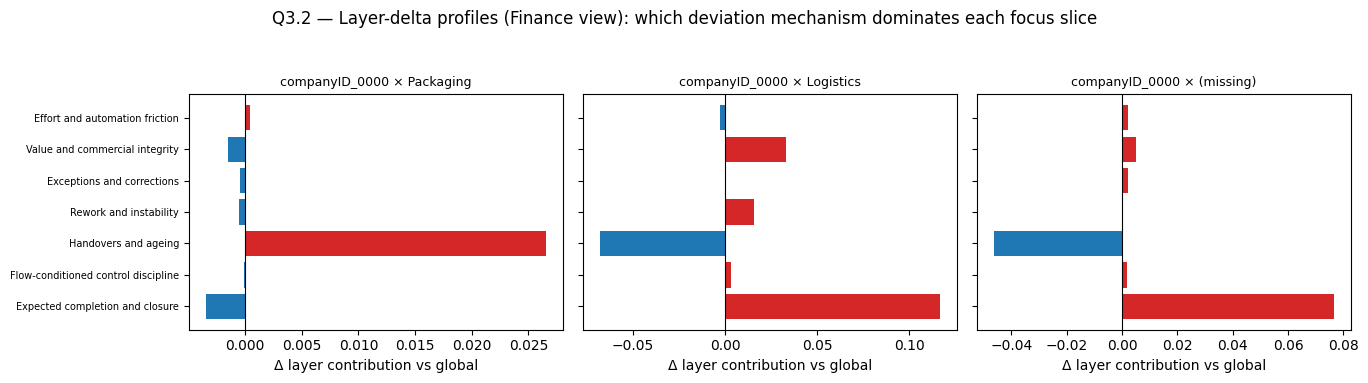

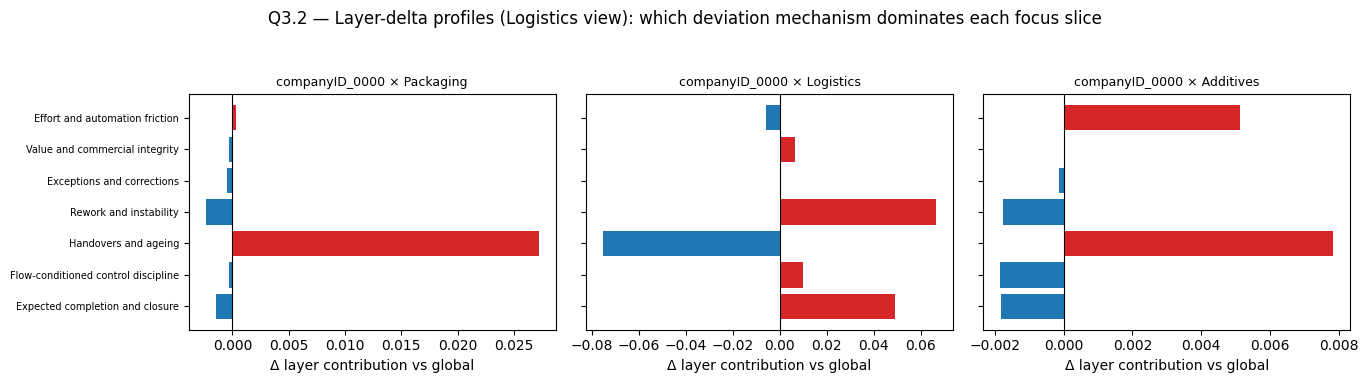

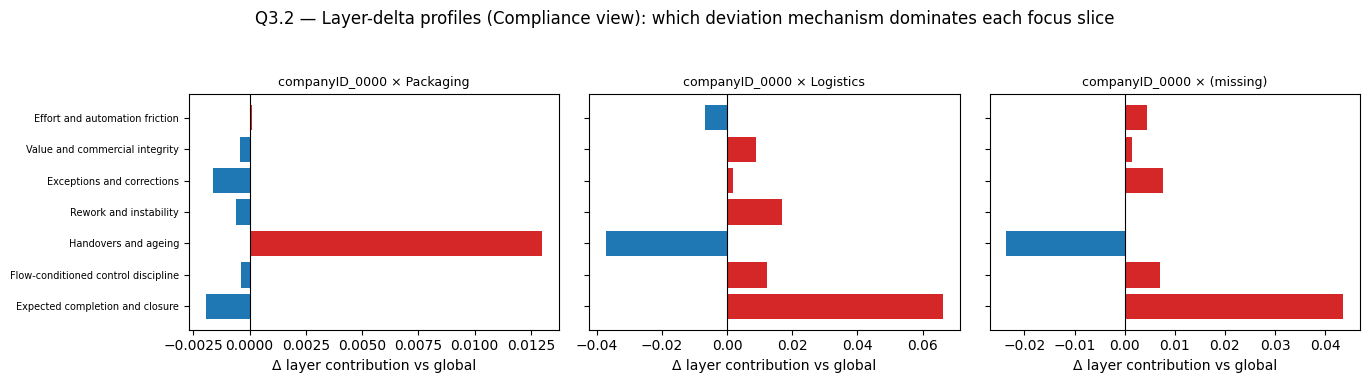

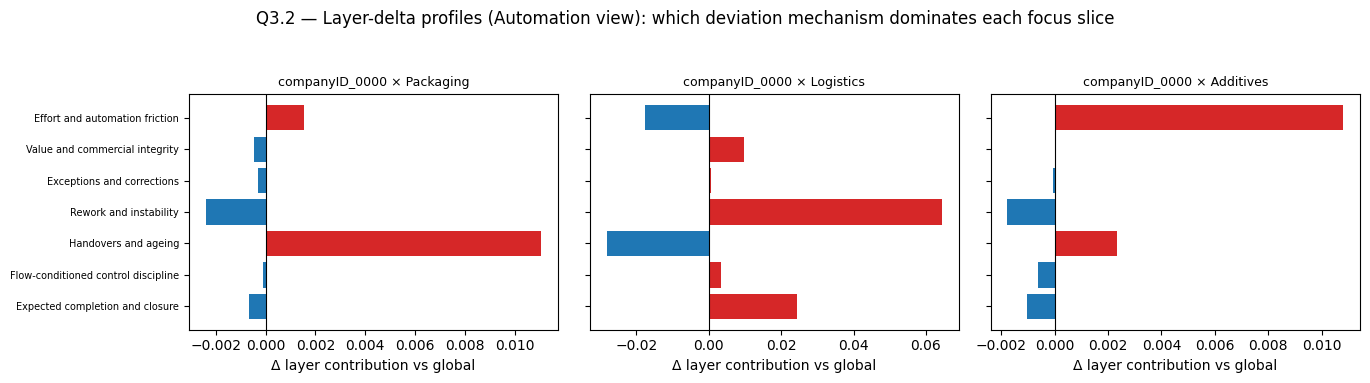

In [12]:
view_focus = {}
for v in VIEWS:
    top3 = [tuple(r[k] for k in SLICE_KEYS) for _, r in typeds[v].head(3).iterrows()]
    view_focus[v] = top3
    deltas = prio.slice_layer_deltas(scores, v, SLICE_KEYS, norm).loc[top3]
    viz.fig_layer_deltas(deltas, norm, v, name=f"layer_deltas_{v.lower()}")
    print(f"{v}: focus slices = " + " | ".join(" × ".join(map(str, s)) for s in top3))



> ### 📖 Reading these figures — *why* each hotspot underperforms (layer deltas)
>
> **What you are looking at.** For each view's top-3 slices, the **difference**
> between the slice's layer profile and the global average. Positive bars =
> mechanisms *more pronounced here than elsewhere*. Crucially, the top slices do
> **not** share a profile: Packaging spikes on **L3 (ageing)**, Logistics on **L4
> (rework/fragmentation)**, smaller slices on approval-related rework.
>
> **Why it matters for the business.** This is the step most dashboards never
> reach: it separates **"where" from "why".** Packaging and Logistics are the two
> biggest hotspots and sit in the same company — but they are **different problems**
> and must not be handled by the same project. Packaging is a *coordination/backlog*
> problem (work piles up and clears slowly); Logistics is an *execution-stability*
> problem (the same item gets received/posted repeatedly). One needs SLA and queue
> management; the other needs redesign of the receiving step.
>
> **What to do with it.** Use the dominant positive bar to **pre-assign the type of
> follow-up** before drilling further: L3 → service-level / escalation work; L4 →
> process redesign or RPA of the repeated step; L7 → automation / touchless-rate
> programme. The layer delta is your routing rule.


## 6 — Mechanism drill-downs (every focus slice) and Q3.3 vendor Paretos

companyID_0000 × Packaging: median 83d vs 55d (×1.52) → body-wide shift → systemic queue problem (SLA/escalation/workload rebalancing)
companyID_0000 × Logistics: median 68d vs 64d (×1.06) → shift AND heavy tail → both queue management and exception triage
companyID_0000 × Additives: median 71d vs 63d (×1.13) → shift AND heavy tail → both queue management and exception triage


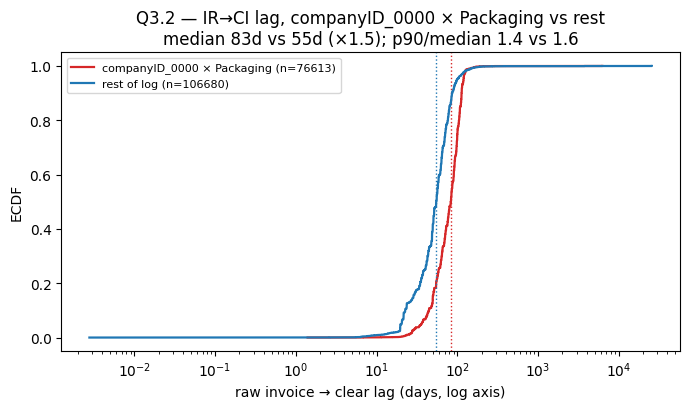

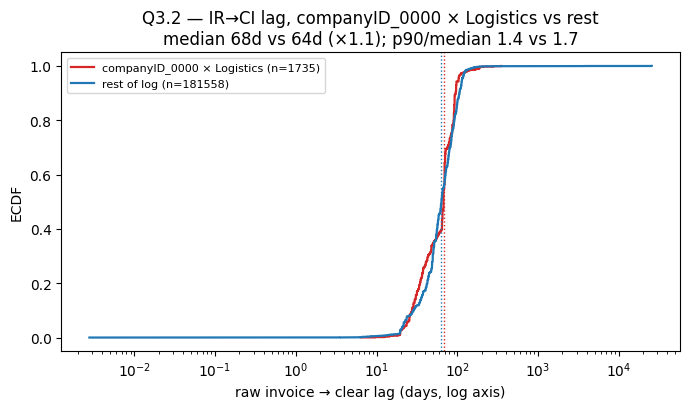

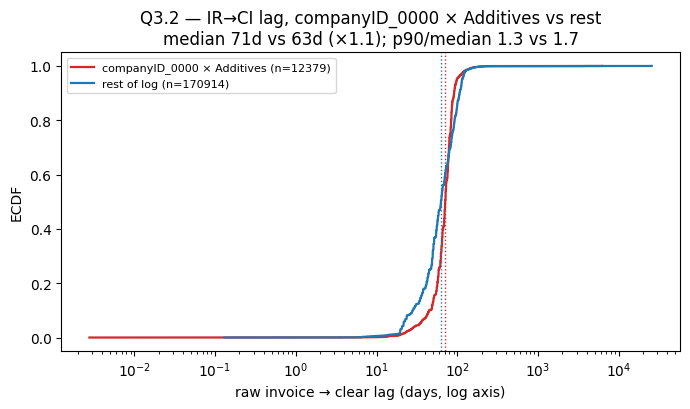

In [13]:
inv_cols = [c for c in ("first_ts__record_invoice_receipt", "first_ts__vendor_creates_invoice")
            if c in scores.columns]
inv_ts = scores[inv_cols].min(axis=1)
lag_days = ((scores.get("first_ts__clear_invoice") - inv_ts).dt.total_seconds() / 86400)
lag_days = lag_days.where(lag_days > 0)
top_auto = view_focus["Automation"]
for sl in top_auto:
    m = (scores[SLICE_KEYS[0]] == sl[0]) & (scores[SLICE_KEYS[1]] == sl[1])
    if lag_days[m].notna().sum() >= 10:
        _, verdict = viz.fig_lag_ecdf(lag_days[m], lag_days[~m], " × ".join(map(str, sl)),
                                      name=f"lag_ecdf_{'_'.join(str(s).lower().replace(' ','') for s in sl)}")
        print(f"{' × '.join(map(str, sl))}: median {verdict['median_in']:.0f}d vs {verdict['median_out']:.0f}d "
              f"(×{verdict['shift_ratio']:.2f}) → {verdict['verdict']}")



> ### 📖 Reading these figures — the *shape* of the delay tells you the cure
>
> **What you are looking at.** ECDFs of the **raw invoice→clear lag** (in days),
> in-slice vs the rest of the log, for the focus slices. The code prints a verdict:
> a **body-wide shift** (the whole curve moves right) vs a **heavy tail** (a normal
> body with a long tail of stuck items).
>
> **Why it matters for the business.** Two delay patterns demand opposite
> interventions, and a single average hides which one you have:
> - **Body-wide shift → a systemic queue problem.** *Everything* is slower here.
>   Cure: capacity, SLAs, escalation rules, workload rebalancing.
> - **Heavy tail → a stuck subpopulation.** Most items clear fine; a identifiable
>   minority is jammed. Cure: targeted **exception triage** of those specific open
>   items — cheap and fast, no process change needed.
>
> Reading the curve shape stops you from launching an expensive capacity programme
> when you actually have 200 stuck invoices to chase (or vice-versa).
>
> **What to do with it.** Take the printed verdict literally as a first-line
> recommendation, then confirm by pulling the tail items and asking AP why those
> specific invoices are open. The shape narrows the question before anyone opens SAP.


Finance    companyID_0000 × Packaging: 19 of 266 vendors carry 80% of penalty
Logistics  companyID_0000 × Packaging: 19 of 266 vendors carry 80% of penalty
Compliance companyID_0000 × Packaging: 20 of 266 vendors carry 80% of penalty
Automation companyID_0000 × Packaging: 22 of 266 vendors carry 80% of penalty


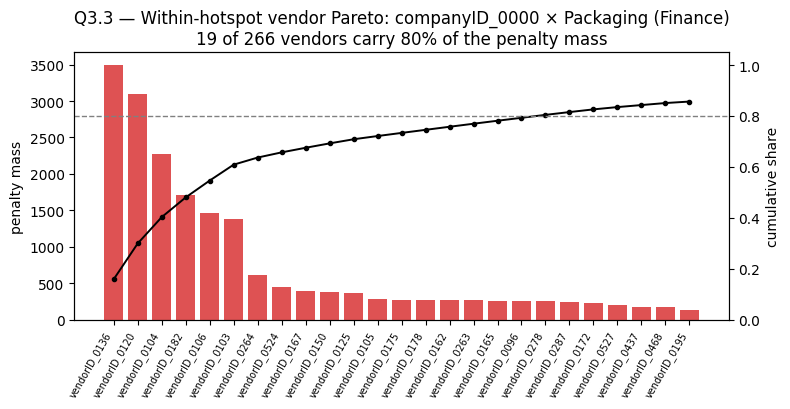

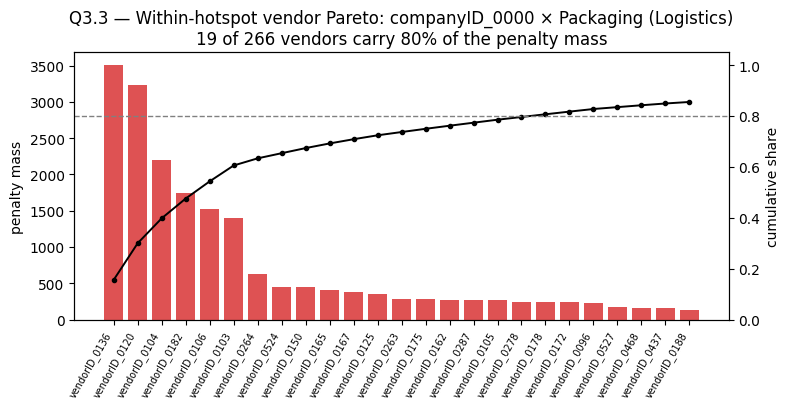

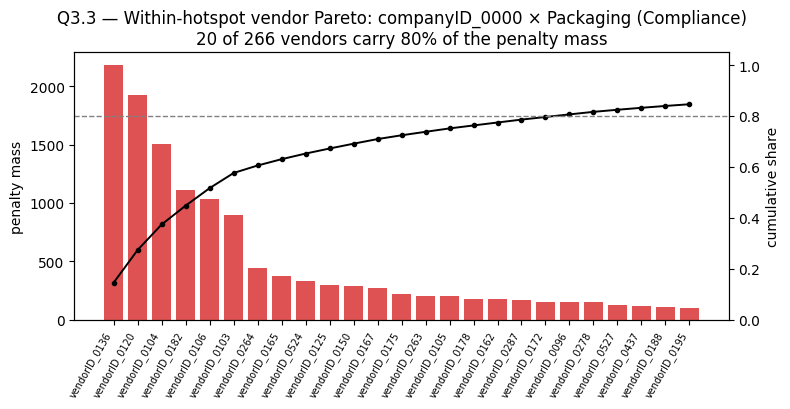

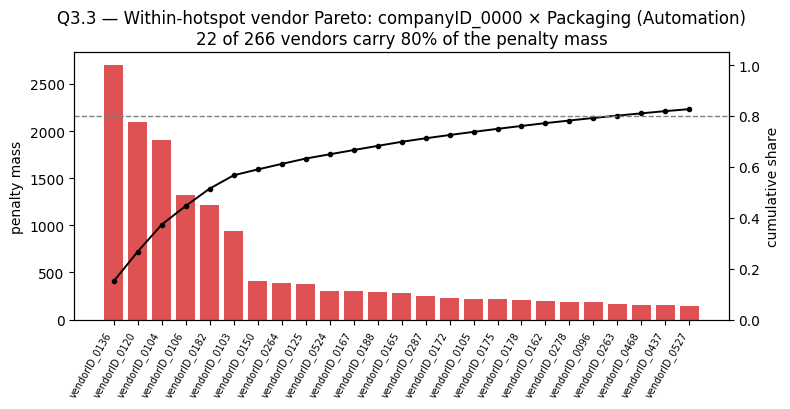

In [14]:
for v in VIEWS:
    sl = view_focus[v][0]
    m = (scores[SLICE_KEYS[0]] == sl[0]) & (scores[SLICE_KEYS[1]] == sl[1])
    pen = (1 - scores.loc[m, f"score__{v}"]).rename("penalty")
    vend = pen.groupby(scores.loc[m, "case Vendor"]).sum().sort_values(ascending=False)
    if len(vend) >= 3:
        _, kk = viz.fig_vendor_pareto(vend, f"{' × '.join(map(str, sl))} ({v})",
                                      name=f"vendor_pareto_{v.lower()}")
        print(f"{v:<10} {' × '.join(map(str, sl))}: {kk['k']} of {kk['K']} vendors carry 80% of penalty")



> ### 📖 Reading these figures — naming the counterparties inside a hotspot
>
> **What you are looking at.** Within each view's top mechanism hotspot, a **Pareto
> of penalty mass over vendors**: bars are per-vendor penalty, the line is the
> cumulative share. A small set of vendors carries ~80% of the slice's penalty.
>
> **Why it matters for the business.** This is the literal answer to the challenge's
> Q3 wording — *which customers/counterparties produce a lot of rework*. It pushes
> the analysis to the level where **commercial levers actually exist**: you cannot
> renegotiate "a spend area", but you *can* renegotiate contracting terms, tighten
> master-data requirements, or change handling policy **with a named vendor**.
>
> **What to do with it.** Take the leading vendors in the Pareto into supplier
> management as a concrete agenda: are their deliveries genuinely more fragmented,
> or is it how *we* receive/post them? That question — supplier behaviour vs our own
> handling — is the fork the rest of the root-cause work (Section 8) resolves.


## 7 — Governance loop for every view: data-quality qualification + quarterly trends

In [15]:
d = gov.add_governance_flags(scores)
print(f"GLOBAL: right-censored {d['is_right_censored'].mean():.1%} of items | "
      f"replicated {d['is_replicated'].mean():.1%} | open invoices {d['is_open_invoice'].mean():.1%}")
print("\nTABLE X (extended) — top-5 Automation slices:")
top5 = [tuple(r[k] for k in SLICE_KEYS) for _, r in typeds["Automation"].head(5).iterrows()]
display(gov.governance_table(d, "Automation", top5, SLICE_KEYS).round(3))


GLOBAL: right-censored 0.0% of items | replicated 1.7% | open invoices 11.2%

TABLE X (extended) — top-5 Automation slices:


,focus_slice,cases,right_censored_share,replicated_event_share,stable_gap_all,stable_gap_excl_censored,gap_retained_excl_censored,reading
0,companyID_0000 × Packaging,109199,0.0,0.000,0.009,0.009,1.0,gap largely retained → hotspot is not a window...
1,companyID_0000 × Logistics,5242,0.0,0.725,0.056,0.056,1.0,gap largely retained → hotspot is not a window...
2,companyID_0000 × Additives,18318,0.0,0.000,0.010,0.010,1.0,gap largely retained → hotspot is not a window...
3,companyID_0000 × Latex & Monomers,5007,0.0,0.000,0.018,0.018,1.0,gap largely retained → hotspot is not a window...
4,companyID_0003 × Real Estate,583,0.0,0.000,0.087,0.087,1.0,gap largely retained → hotspot is not a window...



> ### 📖 Reading this result — separating *process problems* from *data artefacts*
>
> **What you are looking at.** Global data-quality flags plus a per-slice table:
> **right-censored share** (invoice-bearing items still open near the window end —
> may simply have lacked time to finish), **replicated-event share** (a duplication
> detector), and **gap retained excl. censored** (does the hotspot survive when we
> drop the censored items?).
>
> **Why it matters for the business.** This is the credibility firewall. The single
> fastest way to destroy trust in an analytics programme is to send a team to "fix"
> a problem that was a **logging artefact**. The censoring check answers the
> uncomfortable question directly: of the 22.6% open items, **how many are real
> backlog vs just unfinished-at-extraction?** A hotspot whose gap *survives*
> excluding censored items is a real process issue; one whose gap *collapses* was a
> window artefact and should be demoted — automatically, by design, not by argument.
>
> **What to do with it.** Read the **Reading** column as a triage label per slice:
> *"robust → proceed"*, *"elevated replication → verify logging first"*, *"gap
> collapses → demote"*. Only the robust ones earn a process project; the others earn
> a data-quality ticket. This is what stops the backlog from being polluted.


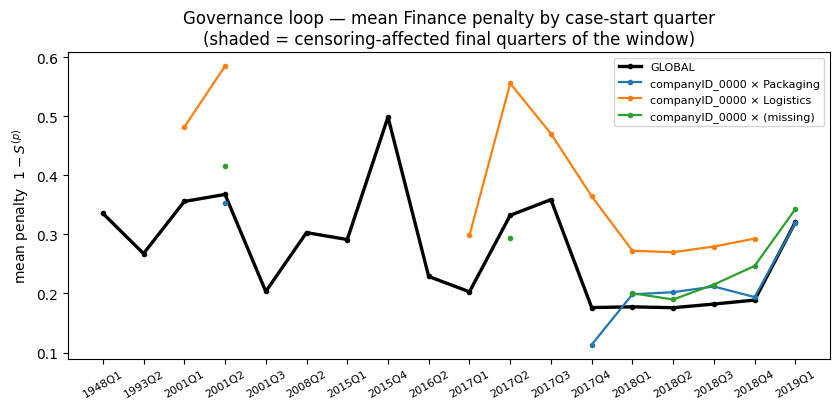

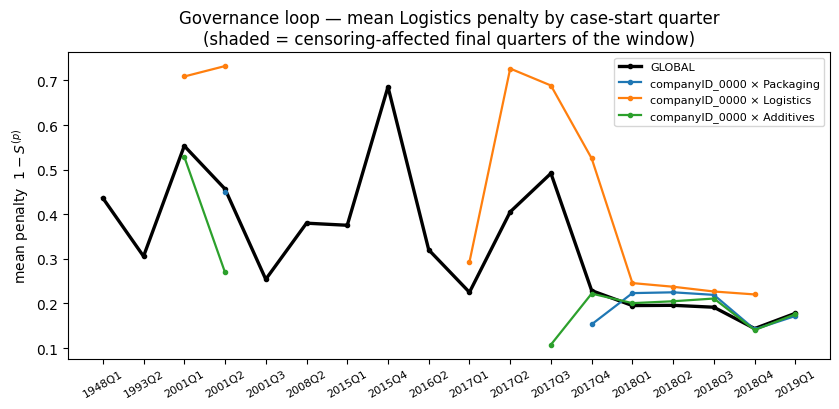

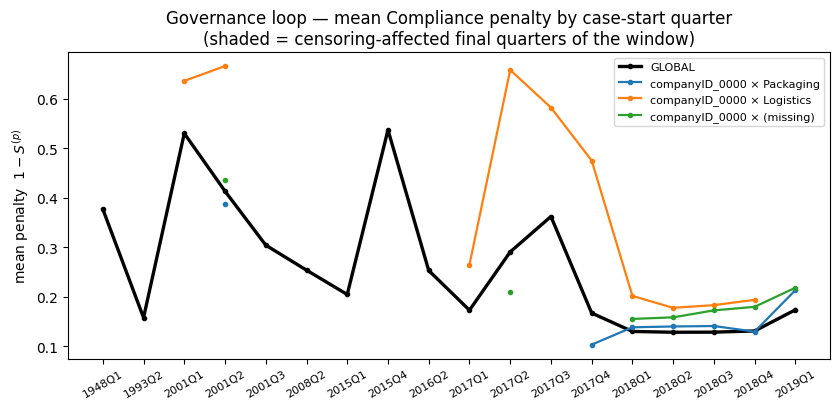

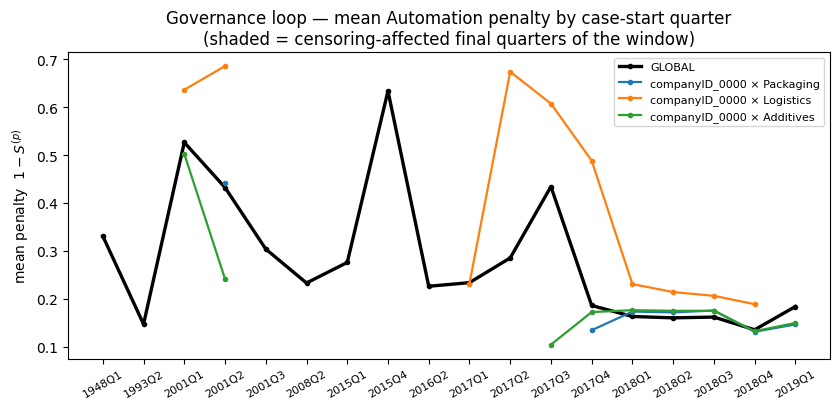

In [16]:
window_end = d["_window_end"].iloc[0]
horizon = window_end - pd.Timedelta(days=CONFIG["censoring_window_days"])
for v in VIEWS:
    trend = gov.quarterly_penalty_trend(d, v, view_focus[v], SLICE_KEYS)
    censor_q = [q for q in trend.index if pd.Period(q).end_time >= horizon]
    viz.fig_quarterly_trend(trend, censor_q, v, name=f"quarterly_trend_{v.lower()}")



> ### 📖 Reading these figures — chronic problem, drift, or end-of-window illusion?
>
> **What you are looking at.** Mean penalty by **case-start quarter** for the focus
> slices vs the global baseline, with the censoring-affected final quarters shaded.
>
> **Why it matters for the business.** The time view tells you whether a hotspot is
> **chronic** (flat-high across all quarters → a standing structural problem worth a
> permanent fix), **drifting** (rising over time → something changed; catch it
> before it worsens), or an **artefact of the shaded final quarters** (penalty only
> spikes where the window cut cases off → not a real deterioration). These three
> imply very different urgency and very different conversations.
>
> **What to do with it.** Only act on signal in the **unshaded** quarters. If a
> slice looks bad only in the shaded zone, its "problem" is mostly truncation — note
> it and move on. If it is high and flat across the whole timeline, it is a genuine
> standing issue and a strong candidate for a permanent process change.


## 8 — Root-cause & explanatory analysis (beyond WISE prioritisation)

WISE tells us **where** deviation concentrates and **which layer** dominates a
slice. This section adds the next analytical step (the paper's *Future Work:
stronger links to root-cause analysis*) with eight complementary methods, all
descriptive — no causal claims. We drill into each view's **top hotspot**.

| Method | Question it answers | Figure |
|---|---|---|
| Constraint prevalence | which individual checks carry the penalty, not just which layer | bar |
| Constraint co-occurrence (lift) | which deviations travel together → shared mechanism | heatmap |
| Contrastive drivers (Cohen's d) | what measurably separates the hotspot from the rest of the log | diverging bar |
| Surrogate decision tree | human-readable threshold rules for a low score | text rules |
| Permutation importance | model-agnostic global drivers of the score | bar |
| Resource hand-off matrix | coordination overhead / segregation-of-duties surface | heatmap |
| Variant severity | which concrete execution sequences are worst | table |
| Value-phase profile | is the deviation in the financially material high-value tail? | bar |


In [17]:
from wise_eval import explain as ex

# One representative hotspot per view = each view's own #1 slice (Section 4).
RC_TARGETS = {v: view_focus[v][0] for v in VIEWS}
print("Root-cause targets (top slice per view):")
for v, sl in RC_TARGETS.items():
    print(f"  {v:<10} → {' × '.join(map(str, sl))}")

# Default deep-dive view = Automation (rework/effort lens, matches paper drill-down)
RC_VIEW = "Automation"
RC_SLICE = RC_TARGETS[RC_VIEW]
rc_mask = ex._slice_mask(scores, SLICE_KEYS, RC_SLICE)
rc_label = " × ".join(map(str, RC_SLICE))
print(f"\nDeep dive: {rc_label}  ({RC_VIEW} view, n = {int(rc_mask.sum()):,} items)")


Root-cause targets (top slice per view):
  Finance    → companyID_0000 × Packaging
  Logistics  → companyID_0000 × Packaging
  Compliance → companyID_0000 × Packaging
  Automation → companyID_0000 × Packaging

Deep dive: companyID_0000 × Packaging  (Automation view, n = 109,199 items)



> ### 📖 What Section 8 adds — from *where/which-layer* to *why*
>
> Sections 1–7 answer **where** deviation concentrates (slices), **for whom** it
> matters (views) and **which layer** dominates. They stop one step short of root
> cause. Section 8 takes that step with eight descriptive methods that drill into a
> chosen hotspot. **Important framing for the business:** these methods *generate
> and rank hypotheses* — they say "this is what most distinguishes the problem area
> and what travels with it" — they do **not** prove cause. They are the structured
> input to a root-cause workshop, replacing "let's stare at some traces" with "here
> are the three drivers most worth testing, ranked."


### 8.1 Constraint prevalence — which checks (not just layers) carry the penalty
Layer deltas show L4 dominates Logistics; this resolves it to the exact
constraint. Global vs in-slice side by side shows what is *specific* to the hotspot.


GLOBAL — top constraints by penalty mass:


,constraint,layer,fire_rate,mean_severity,penalty_mass
0,c_l3_df2_rpb_to_clear_days,L3_timeliness_ageing,0.158,0.671,0.671
1,c_l3_df2_goods_to_rpb_days,L3_timeliness_ageing,0.155,0.658,0.658
2,c_l3_invoice_to_clear_days,L3_timeliness_ageing,0.647,0.559,0.559
3,c_l7_manual_share,L7_effort_automation,0.921,0.536,0.536
4,c_l2_df1_invoice_after_goods,L2_flow_discipline,0.023,0.517,0.517
5,c_l7_distinct_human_resources,L7_effort_automation,0.832,0.442,0.442
6,c_l3_df1_goods_to_invoice_days,L3_timeliness_ageing,0.008,0.228,0.228
7,c_l1_clear_invoice_present,L1_closure_completeness,0.213,0.226,0.226



companyID_0000 × Packaging — top constraints by penalty mass:


,constraint,layer,fire_rate,mean_severity,penalty_mass
0,c_l3_df2_rpb_to_clear_days,L3_timeliness_ageing,0.186,0.752,0.752
1,c_l3_invoice_to_clear_days,L3_timeliness_ageing,0.678,0.731,0.731
2,c_l3_df2_goods_to_rpb_days,L3_timeliness_ageing,0.204,0.713,0.713
3,c_l2_df1_invoice_after_goods,L2_flow_discipline,0.021,0.586,0.586
4,c_l7_manual_share,L7_effort_automation,0.925,0.551,0.551
5,c_l7_distinct_human_resources,L7_effort_automation,0.846,0.464,0.464
6,c_l1_clear_invoice_present,L1_closure_completeness,0.220,0.238,0.238
7,c_l3_df1_goods_to_invoice_days,L3_timeliness_ageing,0.003,0.096,0.096


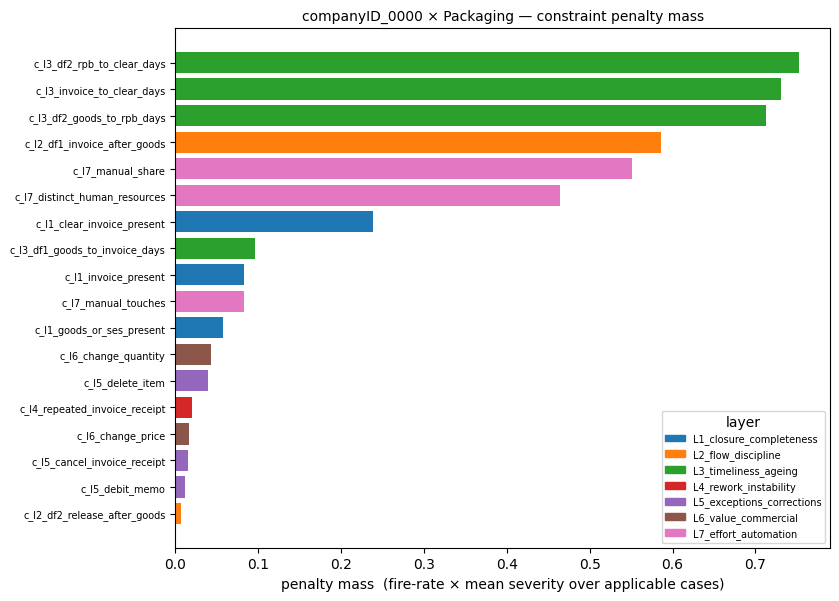

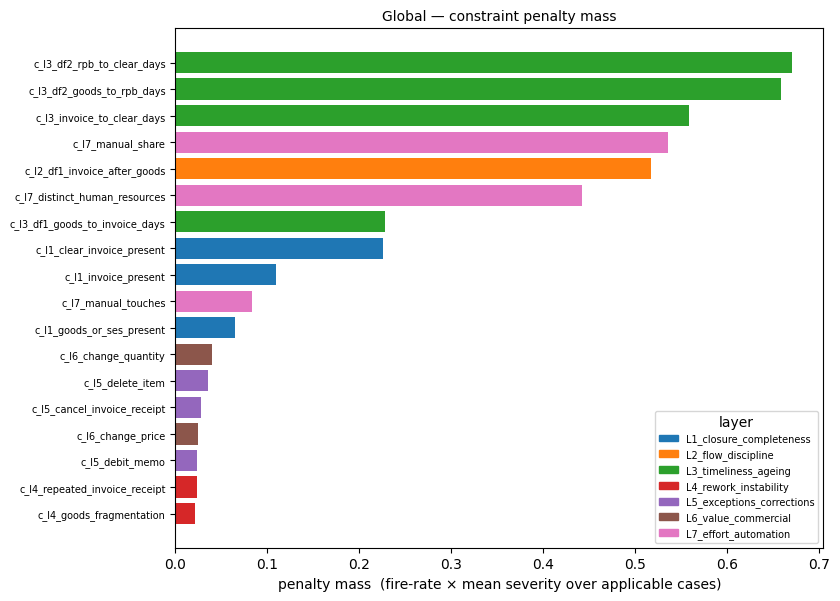

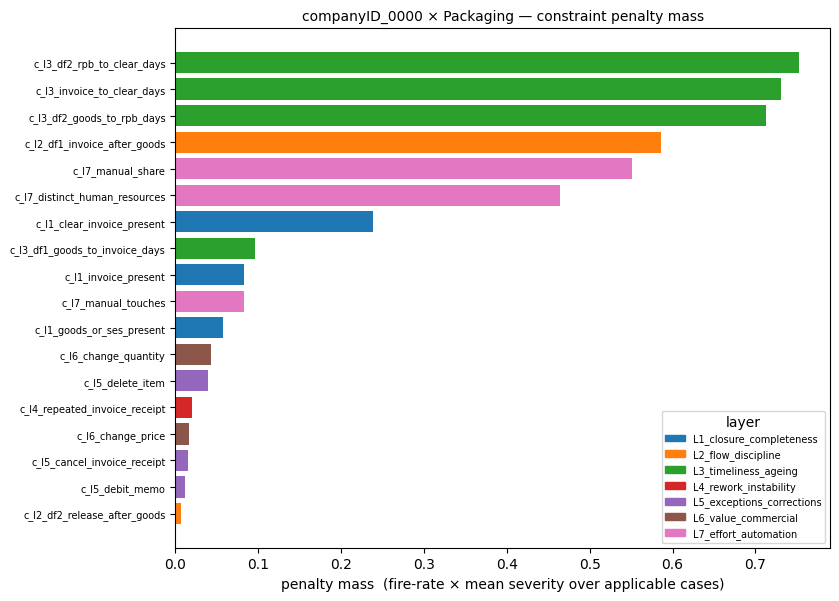

In [18]:
prev_global = ex.constraint_prevalence(scores, norm, mask=None)
prev_slice  = ex.constraint_prevalence(scores, norm, mask=rc_mask)
print("GLOBAL — top constraints by penalty mass:")
display(prev_global.head(8)[["constraint","layer","fire_rate","mean_severity","penalty_mass"]].round(3))
print(f"\n{rc_label} — top constraints by penalty mass:")
display(prev_slice.head(8)[["constraint","layer","fire_rate","mean_severity","penalty_mass"]].round(3))
viz.fig_constraint_prevalence(prev_global, "Global — constraint penalty mass", "rc_prevalence_global")
viz.fig_constraint_prevalence(prev_slice, f"{rc_label} — constraint penalty mass", "rc_prevalence_slice")



> ### 📖 Reading this — which exact *check* carries the penalty (not just the layer)
>
> **What you are looking at.** Per-constraint **penalty mass** (fire-rate × mean
> severity), globally and inside the hotspot, side by side. A layer like "L4 rework"
> contains several checks; this resolves it to the **single constraint** doing the
> damage — e.g. goods-fragmentation rather than approval churn.
>
> **Why it matters for the business.** "Rework is high" is not actionable; "**goods
> are being received in too many fragments on these items**" is. The global-vs-slice
> comparison also separates *what is wrong everywhere* (systemic, tackle in the core
> process) from *what is specific to this hotspot* (local, tackle in the slice). That
> distinction decides whether the fix is a policy change or a local intervention.
>
> **What to do with it.** Take the top one or two in-slice constraints as the named
> defect to investigate. This is the figure that turns a layer label into a
> sentence an operations lead can act on.


### 8.2 Constraint co-occurrence — which deviations travel together
High **lift** between two constraints means they fire together far more than
chance: a structural hint they share one underlying mechanism (e.g. fragmentation
co-occurring with late clearing → a receiving problem that delays settlement).


companyID_0000 × Packaging — constraint pairs that co-occur most (top lift):


,constraint_a,constraint_b,support_both,jaccard,lift
0,c_l6_change_price,c_l6_high_exposure_price_change,3515,1.00,31.05
1,c_l1_goods_or_ses_present,c_l5_delete_item,3867,0.62,16.85
2,c_l1_invoice_present,c_l1_goods_or_ses_present,5738,0.68,12.87
3,c_l1_invoice_present,c_l5_delete_item,3891,0.44,11.82
4,c_l1_invoice_present,c_l1_clear_invoice_present,8324,0.35,4.54
5,c_l1_clear_invoice_present,c_l1_goods_or_ses_present,5745,0.24,4.49
6,c_l1_clear_invoice_present,c_l5_delete_item,3917,0.16,4.14
7,c_l3_df2_goods_to_rpb_days,c_l3_df2_rpb_to_clear_days,15368,0.56,3.71
8,c_l4_repeated_invoice_receipt,c_l7_manual_touches,3418,0.10,3.00
9,c_l6_high_exposure_price_change,c_l7_manual_touches,2965,0.08,2.66


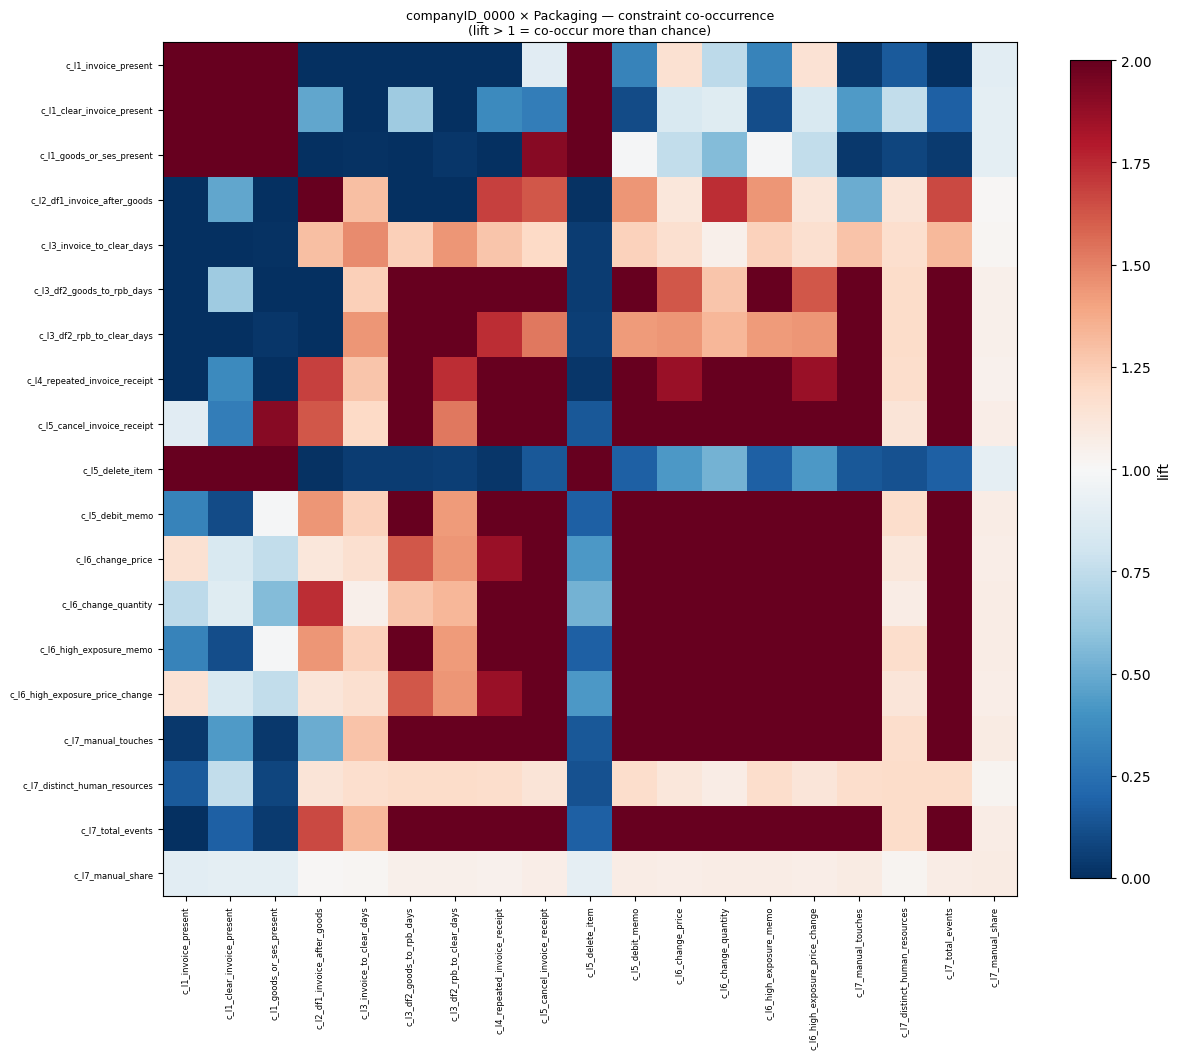

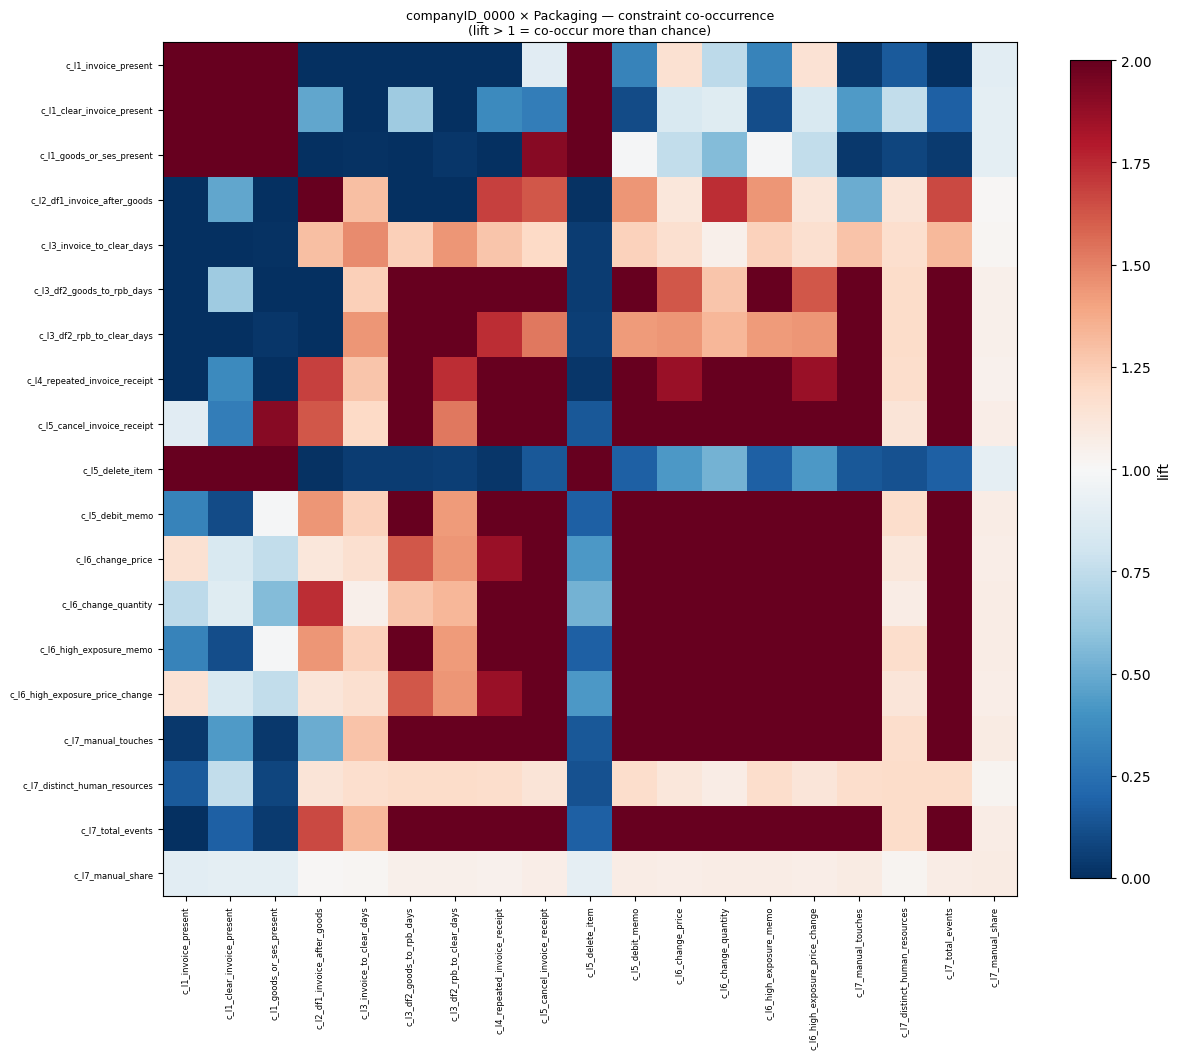

In [19]:
co = ex.constraint_cooccurrence(scores, norm, rc_mask, min_support=max(20, int(rc_mask.sum()*0.02)))
print(f"{rc_label} — constraint pairs that co-occur most (top lift):")
display(co.head(10).round(2))
viz.fig_cooccurrence_heatmap(scores, norm, rc_mask, f"{rc_label} — constraint co-occurrence", "rc_cooccurrence")



> ### 📖 Reading this — which problems are actually *one* problem
>
> **What you are looking at.** Pairwise **lift** between violated constraints inside
> the hotspot. Lift > 1 means two checks fire together far more than chance would
> predict.
>
> **Why it matters for the business.** Deviation lists tempt you to open one ticket
> per red flag. Co-occurrence reveals when several "separate" flags are **facets of
> a single mechanism** — e.g. fragmentation → repeated postings → delayed clearing
> all firing together is *one* receiving problem, not three. Fixing the upstream
> cause clears the whole cluster; chasing them individually wastes effort and can
> even conflict.
>
> **What to do with it.** Look for the tightest cluster (highest mutual lift) and
> treat it as **one hypothesis**: "if we fix the receiving/split-delivery step, do
> the postings and the clearing delay both fall?" That is a single, testable
> redesign question instead of three disconnected fixes.


### 8.3 Contrastive drivers — what separates the hotspot from the rest
Standardized mean difference (Cohen's d) of every feature and constraint,
in-slice vs rest-of-log. This is the core contrastive root-cause view: the bars
at the top are *what makes this slice different*. |d|>0.8 is a large effect.


,feature,in_mean,rest_mean,cohens_d
0,c_l3_invoice_to_clear_days,0.731,0.435,0.926
1,count__receive_order_confirmation,0.230,0.049,0.562
2,c_l3_df1_goods_to_invoice_days,0.096,0.286,-0.540
3,exposure_norm,0.075,0.184,-0.447
4,c_l3_df2_rpb_to_clear_days,0.752,0.589,0.405
5,c_l3_df2_goods_to_rpb_days,0.713,0.598,0.260
6,c_l4_goods_fragmentation,0.003,0.036,-0.235
7,c_l7_total_events,0.002,0.027,-0.228
8,c_l2_df1_invoice_after_goods,0.586,0.479,0.215
9,c_l6_bal_networth_volatility,0.000,0.025,-0.214


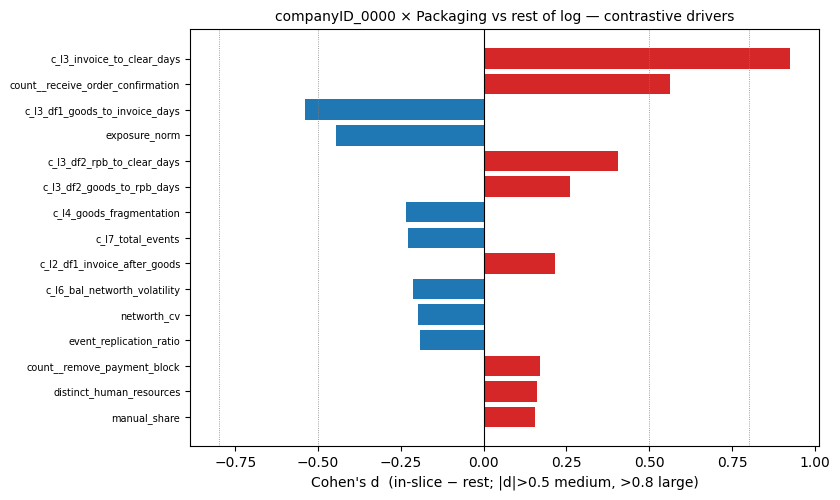

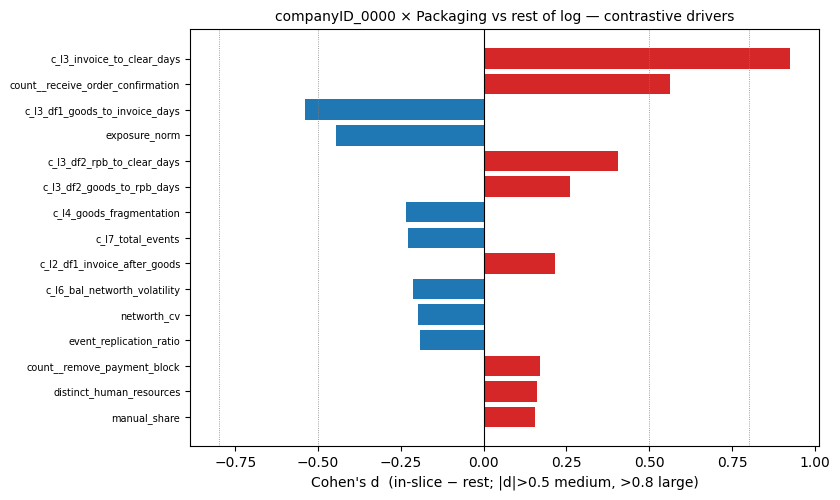

In [20]:
con = ex.contrastive_drivers(scores, norm, rc_mask, top=15)
display(con[["feature","in_mean","rest_mean","cohens_d"]].round(3))
viz.fig_contrastive_drivers(con, f"{rc_label} vs rest of log — contrastive drivers", "rc_contrastive")



> ### 📖 Reading this — what makes the hotspot *different* from everywhere else
>
> **What you are looking at.** **Cohen's *d*** for every feature/constraint:
> in-slice vs the rest of the log. Bars to the right are quantities materially
> higher inside the hotspot; |d|>0.8 is a *large* effect.
>
> **Why it matters for the business.** This is the workhorse contrastive-RCA view.
> Instead of describing the hotspot in absolute terms (which can just reflect the
> kind of work it does), it asks **"what is genuinely unusual here versus the rest
> of the company?"** The top bars are the shortlist of things to investigate — and
> because they are standardized, a fragmentation count and a manual-share ratio can
> be compared on the same scale.
>
> **What to do with it.** The single largest bar is your prime suspect; take the top
> three into the workshop. If the top driver is a *constraint* (e.g.
> goods-fragmentation), it points to process behaviour; if it is a *resource/effort*
> feature (manual share, distinct humans), it points to how the work is staffed and
> handed off. That distinction routes the fix to operations vs org design.


### 8.4 Surrogate decision tree + permutation importance — readable score drivers
A shallow tree approximates "what makes a case a low scorer" with a handful of
thresholds (intrinsic interpretability), and permutation importance gives the
model-agnostic global ranking (the paper's XAI angle: LIME/SHAP family).


Surrogate rules for a bottom-10% Automation score (whole log):

|--- total_events <= 6.50
|   |--- manual_touch_count <= 4.50
|   |   |--- count__change_approval_for_purchase_order <= 0.50
|   |   |   |--- class: 0
|   |   |--- count__change_approval_for_purchase_order >  0.50
|   |   |   |--- class: 1
|   |--- manual_touch_count >  4.50
|   |   |--- count__receive_order_confirmation <= 0.50
|   |   |   |--- class: 0
|   |   |--- count__receive_order_confirmation >  0.50
|   |   |   |--- class: 1
|--- total_events >  6.50
|   |--- manual_touch_count <= 5.50
|   |   |--- total_events <= 21.50
|   |   |   |--- class: 0
|   |   |--- total_events >  21.50
|   |   |   |--- class: 1
|   |--- manual_touch_count >  5.50
|   |   |--- manual_touch_count <= 6.50
|   |   |   |--- class: 1
|   |   |--- manual_touch_count >  6.50
|   |   |   |--- class: 1


Permutation importance (surrogate R² = 0.80):


,feature,importance,std
0,total_events,0.4160,0.0070
1,distinct_human_resources,0.3881,0.0100
2,manual_share,0.2837,0.0059
3,exposure_norm,0.0439,0.0011
4,count__clear_invoice,0.0292,0.0015
5,count__remove_payment_block,0.0155,0.0010
6,count__record_invoice_receipt,0.0152,0.0007
7,count__record_goods_receipt,0.0142,0.0010
8,count__change_approval_for_purchase_order,0.0139,0.0005
9,count__create_purchase_requisition_item,0.0137,0.0003


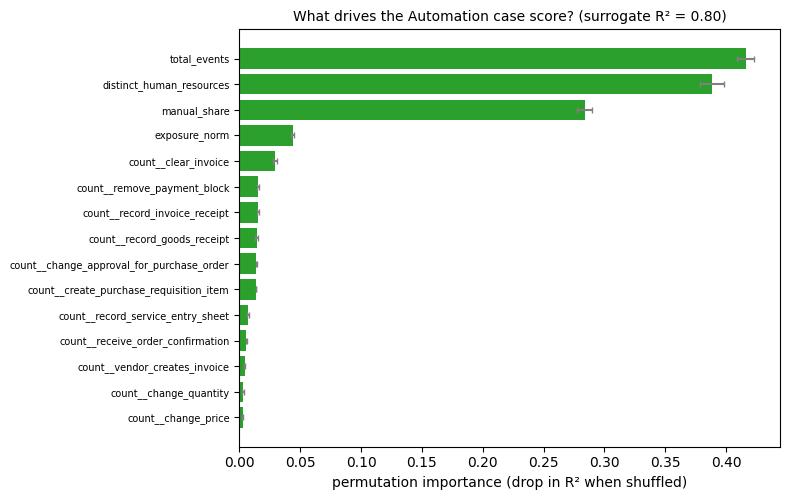

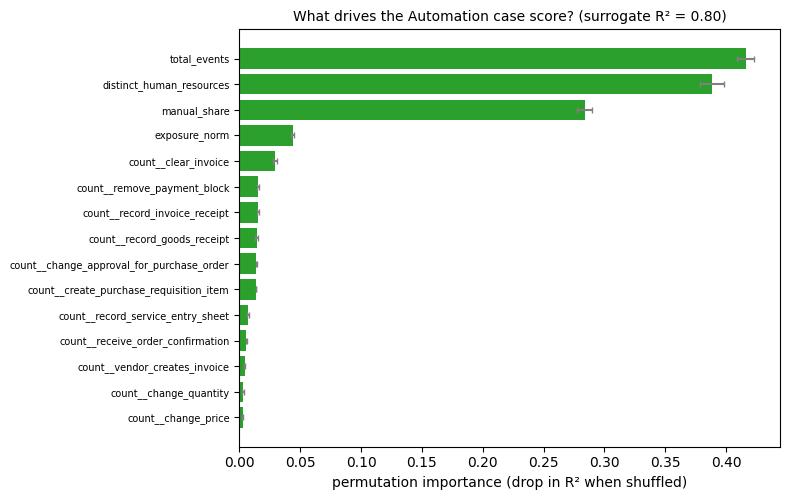

In [21]:
clf, rules, fcols = ex.surrogate_tree_rules(scores, RC_VIEW, max_depth=3, low_quantile=0.10)
print(f"Surrogate rules for a bottom-10% {RC_VIEW} score (whole log):\n")
print(rules)
imp, r2 = ex.permutation_importance_for_score(scores, RC_VIEW, sample=20000, n_repeats=5)
print(f"\nPermutation importance (surrogate R² = {r2:.2f}):")
display(imp.head(10).round(4))
viz.fig_permutation_importance(imp, r2, RC_VIEW, "rc_permutation_importance")



> ### 📖 Reading this — plain-language rules for "what makes a bad case"
>
> **What you are looking at.** A shallow **decision tree** turned into readable
> if-then rules that approximate "is this case a low scorer?", plus **permutation
> importance** ranking which features most drive the score across the whole log.
>
> **Why it matters for the business.** The tree gives stakeholders something they
> can *read and challenge*: "items with more than N manual touches **and** a
> payment-block removal tend to score low." That is a hypothesis a domain expert can
> immediately confirm or reject from experience — exactly the kind of explainable
> output that builds trust in the scoring. Permutation importance is the sanity
> check: it confirms the score is driven by the **intended** operational quantities,
> not by some incidental artefact.
>
> **What to do with it.** Use the rules as **conversation starters** with process
> owners, not as ground truth — they are an approximation. A rule that surprises the
> domain expert is the most valuable: either the model found something real, or it
> exposed a data quirk. Both are worth ten minutes.


### 8.5 Resource hand-off matrix — coordination overhead & SoD surface
Consecutive same-case events by **different** resources are hand-offs. A dense
off-diagonal means many human hand-offs (coordination cost; also the
segregation-of-duties surface the paper flags as a future drill-down).


companyID_0000 × Packaging — top resource→resource hand-offs (count):


,NONE,user_001,user_002,user_006,user_012,user_013,user_015,user_019,user_020,user_029,user_030,user_057,user_235
NONE,0,4888,420,395,5925,4926,265,7165,13067,32,3258,107,16075
user_001,166,0,4746,652,20,37,1147,5,21,1,0,10,7
user_002,68,86,0,15,21,50,220,25,21,0,0,0,14
user_006,91,28,7928,0,8,12,24,8,18,0,0,10,0
user_012,187,20,6743,874,0,52,380,25,9,0,19,5,4
user_013,292,31,4573,457,57,0,1219,35,14,0,4,2,7
user_015,377,53,7619,23,23,35,0,12,21,0,1,5,34
user_019,386,22,6977,568,20,24,827,0,70,0,24,8,7
user_020,407,21,11325,1484,12,36,1214,93,0,4,28,16,8
user_029,4921,6,5,1,3,7,0,8,14,0,5080,16,7


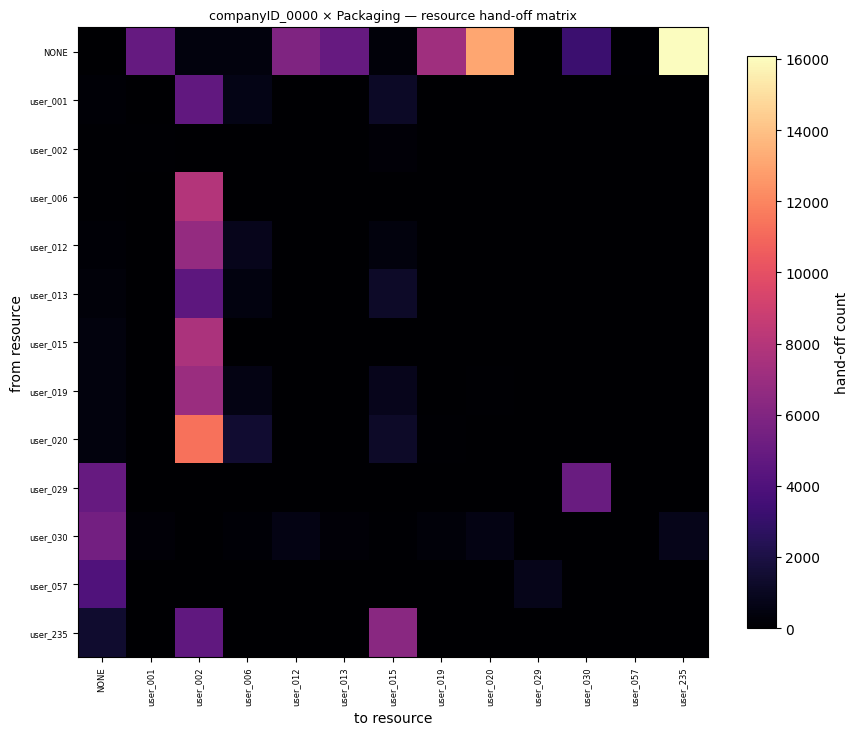

In [22]:
H = ex.resource_handoff_matrix(df, scores.loc[rc_mask, "case_id"], top_resources=12)
print(f"{rc_label} — top resource→resource hand-offs (count):")
display(H)
if H.values.sum() > 0:
    viz.fig_handoff_matrix(H, f"{rc_label} — resource hand-off matrix", "rc_handoff")



> ### 📖 Reading this — the coordination cost and segregation-of-duties surface
>
> **What you are looking at.** A **resource→resource hand-off matrix** inside the
> hotspot: how often work passes from one person/system to another within the same
> case. Dense off-diagonal mass = many human hand-offs.
>
> **Why it matters for the business.** Hand-offs are where time, errors and cost
> accumulate — every pass between people is a queue and a chance for rework. A busy
> hand-off matrix in a *mechanism* hotspot often **explains** the instability the
> layer delta flagged: the item is bouncing between roles. It is also the
> **segregation-of-duties** surface auditors care about — concentrated paths where
> the same pair of resources handles sensitive transitions.
>
> **What to do with it.** Look for two patterns: a **hub resource** everything routes
> through (a capacity bottleneck or key-person risk) and **ping-pong pairs** (work
> bouncing back and forth → unclear ownership). The first is a staffing/automation
> target; the second is a role-clarity fix. Both are concrete redesign levers.


### 8.6 Variant severity — which concrete behaviours are worst
Links the abstract PI hotspot back to real execution sequences: the trace
variants inside the slice ranked by total penalty mass. These are the patterns a
workshop would actually look at.


In [23]:
vt = ex.variant_severity_table(df, scores, RC_VIEW, rc_mask, top=12)
print(f"{rc_label} — worst trace variants by penalty mass:")
display(vt.round(3))


companyID_0000 × Packaging — worst trace variants by penalty mass:


,variant,cases,mean_penalty,penalty_mass
0,Create Purchase Order Item → Record Goods Rece...,18214,0.158,2884.619
1,Create Purchase Order Item → Vendor creates in...,12293,0.164,2010.414
2,Create Purchase Order Item → Receive Order Con...,9385,0.178,1667.333
3,Create Purchase Order Item → Record Goods Rece...,6076,0.187,1135.052
4,Create Purchase Order Item → Vendor creates in...,5416,0.189,1021.859
5,Create Purchase Order Item → Record Goods Receipt,7234,0.090,648.857
6,Create Purchase Order Item → Vendor creates in...,4077,0.159,648.454
7,Create Purchase Order Item → Receive Order Con...,2620,0.164,429.329
8,Create Purchase Order Item → Receive Order Con...,1661,0.232,384.916
9,Create Purchase Order Item → Delete Purchase O...,2419,0.150,363.255



> ### 📖 Reading this — the actual execution sequences that are worst
>
> **What you are looking at.** The top **trace variants** inside the hotspot ranked
> by total penalty mass — the concrete activity sequences (e.g. *receive → receive →
> receive → post → … → clear late*) that carry the problem.
>
> **Why it matters for the business.** This is where the abstraction finally lands
> on something a process owner recognises. Layers and scores are analytical; a
> **variant is the real path an item took**. Showing the two or three worst
> sequences turns the hotspot from a statistic into "yes, I know exactly which way
> these orders go wrong." It is the artefact a redesign workshop actually works on.
>
> **What to do with it.** Take the top variant by penalty mass and walk it
> end-to-end with the team that runs it. Ask at each repeated/late step: *is this
> necessary?* The worst variant is usually the clearest redesign target because it
> combines high frequency with high severity.


### 8.7 Value-phase profile — is the deviation financially material?
Splits the slice into exposure (value) bands and shows where penalty mass sits.
Deviation concentrated in the high-value tail (Q5) is materially different from
the same rate spread over low-value noise — the conservative Q3.3 value reading.


,value_band,cases,mean_penalty,total_exposure,penalty_mass,penalty_mass_share
0,Q1,21840,0.130,54.299,2848.469,0.159
1,Q2,21840,0.162,252.393,3535.165,0.197
2,Q3,21839,0.167,561.771,3654.997,0.204
3,Q4,21840,0.171,1348.343,3743.868,0.209
4,Q5,21840,0.190,5941.119,4159.237,0.232



High-value band (Q5) carries 23% of the slice's penalty mass.


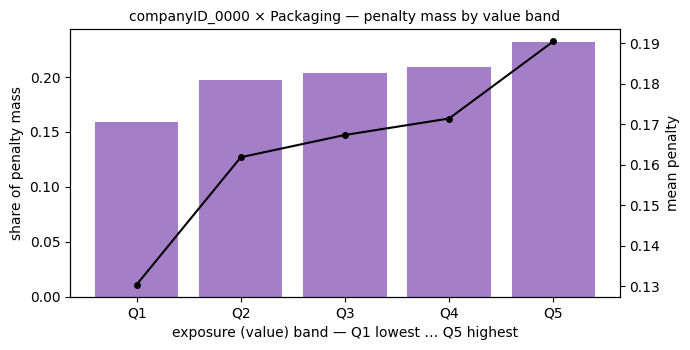

In [24]:
vp = ex.value_phase_profile(scores, RC_VIEW, rc_mask, n_bins=5)
if len(vp):
    display(vp.round(3))
    viz.fig_value_phase(vp, f"{rc_label} — penalty mass by value band", "rc_value_phase")
    hi = vp.loc[vp["value_band"]=="Q5","penalty_mass_share"]
    print(f"\nHigh-value band (Q5) carries {float(hi.iloc[0]):.0%} of the slice's penalty mass.")
else:
    print("Exposure column not available for value-phase profiling.")



> ### 📖 Reading this — is the deviation where the *money* is?
>
> **What you are looking at.** The hotspot's items split into **exposure (value)
> bands** (Q1 low → Q5 high), showing where the penalty mass sits.
>
> **Why it matters for the business.** Not all rework is worth fixing. The same
> defect rate on low-value items is noise; on the high-value tail it is material
> financial and audit risk. If penalty mass concentrates in **Q5 (high value)**, the
> hotspot deserves priority *beyond* its case count — a few large items can justify
> a project on their own. If it sits in the low bands, you may rationally **tolerate**
> it and spend the capacity elsewhere.
>
> **What to do with it.** Use this to *re-weight* the backlog for a finance
> audience: a slice with modest volume but high-value-concentrated penalty is a
> stronger candidate than its raw PI suggests. It is also the honest scoping
> statement — WISE flags *where commercially relevant change behaviour concentrates*,
> not a full invoice-correctness audit, so frame conclusions as exposure, not proven
> loss.


### 8.8 Cross-view root-cause summary
For each view's top hotspot, the single strongest contrastive driver and dominant
constraint — a compact "why" companion to the cross-view backlog of Section 4.


In [25]:
rows = []
for v, sl in RC_TARGETS.items():
    m = ex._slice_mask(scores, SLICE_KEYS, sl)
    if m.sum() < 20:
        continue
    c = ex.contrastive_drivers(scores, norm, m, top=1)
    p = ex.constraint_prevalence(scores, norm, m).head(1)
    rows.append({"view": v, "hotspot": " × ".join(map(str, sl)), "cases": int(m.sum()),
                 "top_contrastive_driver": c.iloc[0]["feature"] if len(c) else "—",
                 "cohens_d": round(float(c.iloc[0]["cohens_d"]), 2) if len(c) else None,
                 "dominant_constraint": p.iloc[0]["constraint"] if len(p) else "—",
                 "constraint_layer": p.iloc[0]["layer"] if len(p) else "—"})
display(pd.DataFrame(rows))


,view,hotspot,cases,top_contrastive_driver,cohens_d,dominant_constraint,constraint_layer
0,Finance,companyID_0000 × Packaging,109199,c_l3_invoice_to_clear_days,0.93,c_l3_df2_rpb_to_clear_days,L3_timeliness_ageing
1,Logistics,companyID_0000 × Packaging,109199,c_l3_invoice_to_clear_days,0.93,c_l3_df2_rpb_to_clear_days,L3_timeliness_ageing
2,Compliance,companyID_0000 × Packaging,109199,c_l3_invoice_to_clear_days,0.93,c_l3_df2_rpb_to_clear_days,L3_timeliness_ageing
3,Automation,companyID_0000 × Packaging,109199,c_l3_invoice_to_clear_days,0.93,c_l3_df2_rpb_to_clear_days,L3_timeliness_ageing



> ### 📖 Reading this — the one-line "why" behind every view's top hotspot
>
> **What you are looking at.** A compact table: for each view's #1 slice, its
> single strongest **contrastive driver** and its dominant **constraint**. It is the
> root-cause companion to the cross-view backlog of Section 4.
>
> **Why it matters for the business.** This is the table you put on one slide. It
> says, in a row each: *here is the top problem area for this stakeholder, and here
> is the one thing most worth investigating about it.* It closes the loop from
> "where" (slice) through "for whom" (view) to "why" (driver) — the full chain a
> steering committee needs to authorise work.
>
> **What to do with it.** Read down the **driver** column: if the same driver
> recurs across views (e.g. ageing/fragmentation), it is a **systemic** target worth
> a core-process programme; if drivers differ per view, each owner gets a different,
> tailored follow-up. Same-driver-across-views is the strongest signal in the whole
> analysis that you have found a root cause, not a symptom.


In [26]:
# Figure index — everything written by this notebook
files = sorted(Path(CONFIG["figures_dir"]).glob("*.png"))
print(f"FIGURE INDEX — {len(files)} files in {CONFIG['figures_dir']}:\n")
for f in files:
    print(f"  {f.name}")


FIGURE INDEX — 40 files in /Users/ula/code/PhD/WISE/WISE/Untitled/figures/full:

  document_pareto_all_views.png
  document_pareto_automation.png
  document_pareto_compliance.png
  document_pareto_finance.png
  document_pareto_logistics.png
  lag_ecdf_companyid_0000_additives.png
  lag_ecdf_companyid_0000_logistics.png
  lag_ecdf_companyid_0000_packaging.png
  lag_ecdf_companyid_0003_realestate.png
  layer_deltas_automation.png
  layer_deltas_compliance.png
  layer_deltas_finance.png
  layer_deltas_logistics.png
  layer_dominance.png
  layer_weights.png
  ownership_heatmap_automation.png
  ownership_heatmap_compliance.png
  ownership_heatmap_finance.png
  ownership_heatmap_logistics.png
  quarterly_trend_automation.png
  quarterly_trend_compliance.png
  quarterly_trend_finance.png
  quarterly_trend_logistics.png
  rc_contrastive.png
  rc_cooccurrence.png
  rc_handoff.png
  rc_permutation_importance.png
  rc_prevalence_global.png
  rc_prevalence_slice.png
  rc_value_phase.png
  risk_mat

---
## Using this output for the paper
The **main-text figures** come from `WISE_BPIC19_paper_story.ipynb`
(`figures/paper/fig04…fig10`).In **appendix /
supplementary** important are: `document_pareto_all_views.png` (shows the
concentration finding holds in all four views), `view_overlap.png` (visual for
finding 6), `layer_dominance.png` (backs the claim *L3 dominant for
Fin/Log/Compl, L7 for Automation* in Q3.2), and the per-view
`risk_matrix_*` / `ownership_heatmap_*` (demonstrates that "the same computations
are available for Finance and Logistics", Sec. V-C).

**Root-cause figures (Section 8, `rc_*`)** are the strongest material for the
paper's *Future Work / discussion* on linking hotspots to root-cause analysis:
`rc_contrastive` (what separates a hotspot from the rest), `rc_cooccurrence`
(which deviations share a mechanism), `rc_permutation_importance` (global score
drivers), and `rc_prevalence_slice` (the exact leading constraint behind a layer
delta). These are descriptive companions — they generate hypotheses for
workshop-based RCA, they do not estimate causal effects.

---
# 🎯 Key insights & recommended next steps

*A standalone executive read-out of the whole analysis. Specific numbers below are
the real-log values reproduced by this notebook; re-run on your data to refresh
them. Everything here is **descriptive decision-support** — it says where to look
and what to test first, not what a fix will be worth.*

## The five insights that matter most

**1. The problem is a backlog, not an anomaly hunt.**
Across all four views the dominant mechanism is **closure and ageing** (L3), not
exotic exceptions. ~22.6% of invoice-bearing items never reach `Clear Invoice` and
~68.7% show positive invoice→clear ageing. *Read:* a large part of the process
behaves like slowly-resolved work-in-progress. The improvement programme should be
framed as **"work down a backlog and tighten settlement timeliness"**, which is far
cheaper and more tractable than a hunt for rare anomalies.

**2. Priority is extremely concentrated — the campaign is bounded.**
**~2–3% of purchasing documents carry ~80% of the priority mass; under 10% carry
95%.** *Read:* you do not need an organisation-wide initiative. A focused team
working a backlog of a couple of thousand documents captures most of the
recoverable value. This is the single most important planning fact in the analysis.

**3. The top hotspots are different problems in the same place.**
`companyID_0000` dominates the ownership map, but its two biggest slices are **not
the same issue**: **Packaging** is a *reservoir* (huge volume × small gap, driven by
L3 ageing — a coordination/backlog problem) while **Logistics** is a *mechanism*
hotspot (smaller, driven by L4 goods-fragmentation — an execution-stability
problem). *Read:* one needs **queue/SLA management**, the other needs **redesign of
the receiving/posting step**. Do not staff them as one project.

**4. The lens is a real decision.** View shortlists diverge sharply in the action
tail even where population scores correlate (Finance–Automation top-20 overlap is
low). *Read:* choosing "the" view silently chooses the backlog for everyone. Run
**Compliance** (control/audit) and **Automation** (efficiency/rework) in parallel
and merge where they agree.

**5. Some of the headline number is measurement, not process.** The governance loop
exists to stop false alarms: part of the 22.6% open-item rate is **right-censoring**
(items unfinished at extraction, not stuck), and at least one slice carries a
master-data gap — the `companyID_0000 × (missing)` spend-area slice. *Read:* qualify
every steering claim with its data-quality check **before** launching work.

## Recommended next steps, in order

1. **Validate before you act (1–2 days).** For each top slice read the Section 7
   table: keep only hotspots whose gap **survives excluding right-censored items**;
   send the rest to a data-quality ticket. Fix the `(missing)` spend-area
   categorisation first — it may be a master-data correction, not a process project.

2. **Split the backlog by hotspot type, not by PI rank.** Route **Packaging →**
   working-capital / SLA & escalation review of invoice-to-clear; **Logistics →**
   process-redesign/RPA review of receiving, posting and split-delivery handling;
   **small severity slices →** a focused local review, not a redesign.

3. **Confirm the delay shape for the reservoir (Section 6 ECDF).** If the Packaging
   invoice→clear curve is a **body-wide shift**, stand up SLA/escalation and capacity
   measures; if it is a **heavy tail**, run targeted exception triage on the specific
   stuck open items. Do not pick the expensive option by default.

4. **Take the mechanism hotspot into supplier management (Section 6 + 8).** Use the
   vendor Pareto to name the counterparties carrying ~80% of the Logistics penalty,
   then use the **contrastive + co-occurrence** drivers to settle the fork:
   *supplier delivery behaviour* vs *our own receiving/posting*. That answer decides
   whether the lever is contracting terms or internal redesign.

5. **Run a root-cause workshop on the worst variants (Section 8.6).** Walk the top
   penalty-mass trace variants end-to-end with the owning team; at each repeated or
   late step ask "is this necessary?". Bring the hand-off matrix (8.5) to spot hub
   bottlenecks and ping-pong ownership.

6. **Weight by value before final scoping (Section 8.7).** Promote slices whose
   penalty concentrates in the high-value (Q5) band even if their case count is
   modest; consider tolerating low-value-concentrated deviation.

7. **Institutionalise the loop.** Freeze the norm, weights and slice definitions as
   a versioned artefact, re-run each period, and track each top slice's stable gap
   over time. The quarterly-trend view (Section 7) then tells you whether an
   intervention actually moved the chronic signal.

## What this analysis deliberately does *not* claim
It does not estimate the **causal effect** of any intervention, audit invoice
correctness, or prove financial loss. High-priority slices are **candidates** whose
drivers are ranked for investigation; realised impact depends on feasibility and
root causes confirmed in the follow-up above. Validate against SAP configuration,
master data and local process knowledge before committing change.
